#Pontifícia Universidade Católica do Rio de Janeiro

## Data Engineering MVP

#### Author: Felipe da Silva Angnes

#### Professors: Sérgio Lifschitz, Fernanda Baião, Antony Seabra de Medeiros, Marcos Vianna Villas, Carlos Barbieri, Victor Almeida and Jose Matheus Boaro

# 1. Introduction

The present document aims to describe the process carried out during the minimum viable product (MVP) development as the final project for the Data Engineering course, which is the last module of my Data Science and Analytics specialization at Pontifícia Universidade Católica do Rio de Janeiro (PUC-RJ).

This work presents a reasearch subject elaboration that must be addressed using data. The document is structured as follows: section 2 presents the problem definition, where we will elaborate questions to be addressed through data; section 3 explaing the data seach phase; section 4 shows the data collect and store process; section 5 presents all actions made regarding data quality; section 6 explain the approach used as data architecture; section 7 presents the data analysis phase; section 8 conclude this document.

# 2. Problem Definition

During this specialization I have consistently chosen to work with a health related database, so I can try to help people by applying my technical knowledge and studies. For this project I will follow the same approach. Since I have to elaborate some problem/questions that must be addressed using data, I would like to explore the following:

1) What are the global health indicators?
2) Which continents are the healthiest and unhealthiest?
3) What is the impact of Gross Domestic Product (GDP) on a country's population health?
4) What are the health differences between women and men?
5) Which countries have the highest and lowest child mortality rates?

# 3. Data Search

As suggested in the MVP announcement, I accessed the following websites to search for a dataset that could help answer our questions:

- [Google Cloud Public Datasets](https://cloud.google.com/datasets)
- [Kaggle](https://www.kaggle.com/datasets)
- [Brazilian transparency portal](https://portaldatransparencia.gov.br/)
- [IMDB public datasets](https://datasets.imdbws.com/)
- [Tableau free public datasets](https://www.tableau.com/learn/articles/free-public-data-sets)
- [Stanford Large Network Dataset Collection](https://snap.stanford.edu/data/index.html)
- [Yelp Open Dataset](https://www.yelp.ca/dataset)

In Tableau free public datasets I found some health-related datasets that could address our problem. I chose the [Tuberculosis Burden by Country](https://public.tableau.com/app/sample-data/TB_Burden_Country.csv) dataset, which contains data regarding the estimating prevalence and mortality of tuberculosis by country. This dataset is provided by [World Health Organization](https://www.who.int/data/) (WHO) and is licensed under the [Creative Commons Attribution 3.0 Intergovernmental](https://creativecommons.org/licenses/by/3.0/igo/legalcode.en) (CC BY 3.0 IGO)

# 4. Data Collect

## 4.1 Notebook Configuration

To enable the correct WHO dataset loading it is required to configure the notebook appropriately. In the code cell below, we import the required libraries to load the dataset and perform further analysis through graphical plots.

In [0]:
import pandas as pd               # To enable dataset loading and graphical plots
import seaborn as sns             # To be used in graphical plots analysis
import matplotlib.pyplot as plt   # To be used in graphical plots analysis

## 4.2 Dataset Loading and Store

Now that the notebook is configured with the necessary libraries, it is possible to retrieve the dataset from the provided link as shown in the cell below. A sample of the dataset is also displayed in order to perform a first visual analysis of the dataset.

It was necessary to first retrieve the dataset into a Pandas DataFrame because Spark does not support the HTTPS protocol and therefore cannot read directly from an internet link. After loading the dataset using Pandas, a Spark DataFrame is created to perform the required tasks using the Spark library, as it is the core processing engine used in Databricks.

In [0]:
# Retrieving dataset
csv = pd.read_csv("https://public.tableau.com/app/sample-data/TB_Burden_Country.csv")

bronze_df = spark.createDataFrame(csv)
display(bronze_df.limit(10))

Country or territory name,ISO 2-character country/territory code,ISO 3-character country/territory code,ISO numeric country/territory code,Region,Year,Estimated total population number,Estimated prevalence of TB (all forms) per 100 000 population,"Estimated prevalence of TB (all forms) per 100 000 population, low bound","Estimated prevalence of TB (all forms) per 100 000 population, high bound",Estimated prevalence of TB (all forms),"Estimated prevalence of TB (all forms), low bound","Estimated prevalence of TB (all forms), high bound",Method to derive prevalence estimates,"Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound","Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound","Estimated number of deaths from TB (all forms, excluding HIV)","Estimated number of deaths from TB (all forms, excluding HIV), low bound","Estimated number of deaths from TB (all forms, excluding HIV), high bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound","Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound",Estimated number of deaths from TB in people who are HIV-positive,"Estimated number of deaths from TB in people who are HIV-positive, low bound","Estimated number of deaths from TB in people who are HIV-positive, high bound",Method to derive mortality estimates,Estimated incidence (all forms) per 100 000 population,"Estimated incidence (all forms) per 100 000 population, low bound","Estimated incidence (all forms) per 100 000 population, high bound",Estimated number of incident cases (all forms),"Estimated number of incident cases (all forms), low bound","Estimated number of incident cases (all forms), high bound",Method to derive incidence estimates,Estimated HIV in incident TB (percent),"Estimated HIV in incident TB (percent), low bound","Estimated HIV in incident TB (percent), high bound",Estimated incidence of TB cases who are HIV-positive per 100 000 population,"Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound","Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound",Estimated incidence of TB cases who are HIV-positive,"Estimated incidence of TB cases who are HIV-positive, low bound","Estimated incidence of TB cases who are HIV-positive, high bound",Method to derive TBHIV estimates,"Case detection rate (all forms), percent","Case detection rate (all forms), percent, low bound","Case detection rate (all forms), percent, high bound"
Afghanistan,AF,AFG,4,EMR,1990,11731193,306.0,156.0,506.0,36000.0,18000.0,59000.0,predicted,37.0,24.0,54.0,4300.0,2800.0,6400.0,0.04,0.03,0.05,5.0,4.1,6.0,Indirect,189.0,157.0,238.0,22000.0,18000.0,28000.0,null,0.06,0.04,0.08,0.11,0.08,0.14,12.0,9.4,16.0,null,20.0,15.0,24.0
Afghanistan,AF,AFG,4,EMR,1991,12612043,343.0,178.0,562.0,43000.0,22000.0,71000.0,predicted,46.0,29.0,61.0,5800.0,3700.0,7700.0,0.06,0.05,0.08,8.0,6.2,10.0,Indirect,191.0,167.0,227.0,24000.0,21000.0,29000.0,null,0.07,0.06,0.09,0.13,0.11,0.16,17.0,14.0,20.0,null,96.0,80.0,110.0
Afghanistan,AF,AFG,4,EMR,1992,13811876,371.0,189.0,614.0,51000.0,26000.0,85000.0,predicted,54.0,34.0,68.0,7400.0,4700.0,9400.0,0.08,0.06,0.1,11.0,8.3,14.0,Indirect,191.0,171.0,217.0,26000.0,24000.0,30000.0,null,0.08,0.07,0.1,0.16,0.14,0.18,22.0,19.0,24.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1993,15175325,392.0,194.0,657.0,59000.0,30000.0,100000.0,predicted,60.0,38.0,73.0,9100.0,5800.0,11000.0,0.11,0.09,0.14,17.0,13.0,21.0,Indirect,189.0,171.0,209.0,29000.0,26000.0,32000.0,null,0.1,0.09,0.11,0.19,0.17,0.21,28.0,25.0,31.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1994,16485018,410.0,198.0,697.0,68000.0,33000.0,110000.0,predicted,65.0,41.0,79.0,11000.0,6800.0,13000.0,0.13

It is possible to notice that the column names contain spaces and are not according the best practices for naming columns in a table that will be stored in a database. Therefore, the first step is to review all column names and assign more appropriate ones that follow naming conventions (such as using lowercase letters and separating words with underscores).

In [0]:
# Create a temporary view to enable the usage of SQL to manipulate the table
bronze_df.createOrReplaceTempView("bronze_df")

In [0]:
%sql
-- List all columns names and data types
describe table bronze_df

col_name,data_type,comment
Country or territory name,string,null
ISO 2-character country/territory code,string,null
ISO 3-character country/territory code,string,null
ISO numeric country/territory code,bigint,null
Region,string,null
Year,bigint,null
Estimated total population number,bigint,null
Estimated prevalence of TB (all forms) per 100 000 population,double,null
"Estimated prevalence of TB (all forms) per 100 000 population, low bound",double,null
"Estimated prevalence of TB (all forms) per 100 000 population, high bound",double,null


By analyzing the column names, the new column names are as follows:
| Original column name | New column name |
|----------------------|-----------------|
|Country or territory name | country_name|
|ISO 2-character country/territory code | iso2_code|
|ISO 3-character country/territory code | iso3_code|
|ISO numeric country/territory code | iso_numeric_code|
|Region | region|
|Year | year|
|Estimated total population number | total_population|
|Estimated prevalence of TB (all forms) per 100 000 population | tbc_prevalence_per_100k|
|Estimated prevalence of TB (all forms) per 100 000 population, low bound | tbc_prevalence_per_100k_low|
|Estimated prevalence of TB (all forms) per 100 000 population, high bound | tbc_prevalence_per_100k_high|
|Estimated prevalence of TB (all forms) | tbc_prevalence|
|Estimated prevalence of TB (all forms), low bound | tbc_prevalence_low|
|Estimated prevalence of TB (all forms), high bound | tbc_prevalence_high|
|Method to derive prevalence estimates | prevalence_method|
|Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population | tbc_mortality_no_hiv_per_100k|
|Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound | tbc_mortality_no_hiv_per_100k_low|
|Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound | tbc_mortality_no_hiv_per_100k_high|
|Estimated number of deaths from TB (all forms, excluding HIV) | tbc_deaths_no_hiv|
|Estimated number of deaths from TB (all forms, excluding HIV), low bound | tbc_deaths_no_hiv_low|
|Estimated number of deaths from TB (all forms, excluding HIV), high bound | tbc_deaths_no_hiv_high|
|Estimated mortality of TB cases who are HIV-positive, per 100 000 population | tbc_mortality_hiv_per_100k|
|Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound | tbc_mortality_hiv_per_100k_low|
|Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound | tbc_mortality_hiv_per_100k_high|
|Estimated number of deaths from TB in people who are HIV-positive | tbc_deaths_hiv|
|Estimated number of deaths from TB in people who are HIV-positive, low bound | tbc_deaths_hiv_low|
|Estimated number of deaths from TB in people who are HIV-positive, high bound | tbc_deaths_hiv_high|
|Method to derive mortality estimates | mortality_method|
|Estimated incidence (all forms) per 100 000 population | tbc_incidence_per_100k|
|Estimated incidence (all forms) per 100 000 population, low bound | tbc_incidence_per_100k_low|
|Estimated incidence (all forms) per 100 000 population, high bound | tbc_incidence_per_100k_high|
|Estimated number of incident cases (all forms) | tbc_incident_cases|
|Estimated number of incident cases (all forms), low bound | tbc_incident_cases_low|
|Estimated number of incident cases (all forms), high bound | tbc_incident_cases_high|
|Method to derive incidence estimates | incidence_method|
|Estimated HIV in incident TB (percent) | hiv_incident_tbc_percent|
|Estimated HIV in incident TB (percent), low bound | hiv_incident_tbc_percent_low|
|Estimated HIV in incident TB (percent), high bound | hiv_incident_tbc_percent_high|
|Estimated incidence of TB cases who are HIV-positive per 100 000 population | tbc_incidence_hiv_per_100k|
|Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound | tbc_incidence_hiv_per_100k_low|
|Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound | tbc_incidence_hiv_per_100k_high|
|Estimated incidence of TB cases who are HIV-positive | tbc_incidence_hiv|
|Estimated incidence of TB cases who are HIV-positive, low bound | tbc_incidence_hiv_low|
|Estimated incidence of TB cases who are HIV-positive, high bound | tbc_incidence_hiv_high|
|Method to derive TBHIV estimates | tbhiv_method|
|Case detection rate (all forms), percent | tbc_case_detection_rate|
|Case detection rate (all forms), percent, low bound | tbc_case_detection_rate_low|
|Case detection rate (all forms), percent, high bound | tbc_case_detection_rate_high|

The cell below rename all the columns of the temporary view

In [0]:
%sql
create or replace temp view bronze_df_columns_renamed as
select
  `Country or territory name` as country_name,
  `ISO 2-character country/territory code` as iso2_code,
  `ISO 3-character country/territory code` as iso3_code,
  `ISO numeric country/territory code` as iso_numeric_code,
  `Region` as region,
  `Year` as year,
  `Estimated total population number` as total_population,
  `Estimated prevalence of TB (all forms) per 100 000 population` as tbc_prevalence_per_100k,
  `Estimated prevalence of TB (all forms) per 100 000 population, low bound` as tbc_prevalence_per_100k_low,
  `Estimated prevalence of TB (all forms) per 100 000 population, high bound` as tbc_prevalence_per_100k_high,
  `Estimated prevalence of TB (all forms)` as tbc_prevalence,
  `Estimated prevalence of TB (all forms), low bound` as tbc_prevalence_low,
  `Estimated prevalence of TB (all forms), high bound` as tbc_prevalence_high,
  `Method to derive prevalence estimates` as prevalence_method,
  `Estimated mortality of TB cases (all forms, excluding HIV) per 100 000 population` as tbc_mortality_no_hiv_per_100k,
  `Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, low bound` as tbc_mortality_no_hiv_per_100k_low,
  `Estimated mortality of TB cases (all forms, excluding HIV), per 100 000 population, high bound` as tbc_mortality_no_hiv_per_100k_high,
  `Estimated number of deaths from TB (all forms, excluding HIV)` as tbc_deaths_no_hiv,
  `Estimated number of deaths from TB (all forms, excluding HIV), low bound` as tbc_deaths_no_hiv_low,
  `Estimated number of deaths from TB (all forms, excluding HIV), high bound` as tbc_deaths_no_hiv_high,
  `Estimated mortality of TB cases who are HIV-positive, per 100 000 population` as tbc_mortality_hiv_per_100k,
  `Estimated mortality of TB cases who are HIV-positive, per 100 000 population, low bound` as tbc_mortality_hiv_per_100k_low,
  `Estimated mortality of TB cases who are HIV-positive, per 100 000 population, high bound` as tbc_mortality_hiv_per_100k_high,
  `Estimated number of deaths from TB in people who are HIV-positive` as tbc_deaths_hiv,
  `Estimated number of deaths from TB in people who are HIV-positive, low bound` as tbc_deaths_hiv_low,
  `Estimated number of deaths from TB in people who are HIV-positive, high bound` as tbc_deaths_hiv_high,
  `Method to derive mortality estimates` as mortality_method,
  `Estimated incidence (all forms) per 100 000 population` as tbc_incidence_per_100k,
  `Estimated incidence (all forms) per 100 000 population, low bound` as tbc_incidence_per_100k_low,
  `Estimated incidence (all forms) per 100 000 population, high bound` as tbc_incidence_per_100k_high,
  `Estimated number of incident cases (all forms)` as tbc_incident_cases,
  `Estimated number of incident cases (all forms), low bound` as tbc_incident_cases_low,
  `Estimated number of incident cases (all forms), high bound` as tbc_incident_cases_high,
  `Method to derive incidence estimates` as incidence_method,
  `Estimated HIV in incident TB (percent)` as hiv_incident_tbc_percent,
  `Estimated HIV in incident TB (percent), low bound` as hiv_incident_tbc_percent_low,
  `Estimated HIV in incident TB (percent), high bound` as hiv_incident_tbc_percent_high,
  `Estimated incidence of TB cases who are HIV-positive per 100 000 population` as tbc_incidence_hiv_per_100k,
  `Estimated incidence of TB cases who are HIV-positive per 100 000 population, low bound` as tbc_incidence_hiv_per_100k_low,
  `Estimated incidence of TB cases who are HIV-positive per 100 000 population, high bound` as tbc_incidence_hiv_per_100k_high,
  `Estimated incidence of TB cases who are HIV-positive` as tbc_incidence_hiv,
  `Estimated incidence of TB cases who are HIV-positive, low bound` as tbc_incidence_hiv_low,
  `Estimated incidence of TB cases who are HIV-positive, high bound` as tbc_incidence_hiv_high,
  `Method to derive TBHIV estimates` as tbhiv_method,
  `Case detection rate (all forms), percent` as tbc_case_detection_rate,
  `Case detection rate (all forms), percent, low bound` as tbc_case_detection_rate_low,
  `Case detection rate (all forms), percent, high bound` as tbc_case_detection_rate_high
from
  bronze_df;

Now it is performed a check in order to ensure that all columns were renamed as desired.

In [0]:
%sql
describe table bronze_df_columns_renamed

col_name,data_type,comment
country_name,string,null
iso2_code,string,null
iso3_code,string,null
iso_numeric_code,bigint,null
region,string,null
year,bigint,null
total_population,bigint,null
tbc_prevalence_per_100k,double,null
tbc_prevalence_per_100k_low,double,null
tbc_prevalence_per_100k_high,double,null


In order to improve data quality, clarity, and the overall usability of our data architecture, we will implement the Medallion Data Architecture. This architecture is composed of three data layers: Bronze, Silver, and Gold. These layers are described below:

- Bronze Layer: This layer contains data exactly as collected from the source, commonly referred to as raw data. This approach ensures traceability from processed data back to the original source and allows for reprocessing when needed.

- Silver Layer: This layer stores pre-processed data from the Bronze layer. Data cleaning is performed here, including removing nulls, correcting data types, deduplication, and other transformations to improve data quality.

- Gold Layer: The most refined layer contains data that is ready for use in business analytics and reporting.

As this work is being implemented in Databricks, the layers will be implemented as different schemas. In the cell code below is created the bronze layer.

In [0]:
%sql
create schema if not exists bronze;

The table that will store the raw data in the bronze layer has now been created. The original column names were used as comments for each column in order to build the catalog for this raw table. Since the original names are very descriptive, they were retained in the table catalog.

In [0]:
%sql
create or replace table hive_metastore.bronze.tb_burden_country_raw (
  country_name	string	comment	'Country or territory name',
  iso2_code	string	comment	'ISO 2-character country/territory code',
  iso3_code	string	comment	'ISO 3-character country/territory code',
  iso_numeric_code	bigint	comment	'ISO numeric country/territory code',
  region	string	comment	'Region',
  year	bigint	comment	'Year',
  total_population	bigint	comment	'Estimated total population number',
  tbc_prevalence_per_100k	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population',
  tbc_prevalence_per_100k_low	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population, low bound',
  tbc_prevalence_per_100k_high	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population, high bound',
  tbc_prevalence	double	comment	'Estimated prevalence of TB (all forms)',
  tbc_prevalence_low	double	comment	'Estimated prevalence of TB (all forms), low bound',
  tbc_prevalence_high	double	comment	'Estimated prevalence of TB (all forms), high bound',
  prevalence_method	string	comment	'Method to derive prevalence estimates',
  tbc_mortality_no_hiv_per_100k	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV) per 100.000 population',
  tbc_mortality_no_hiv_per_100k_low	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV), per 100.000 population, low bound',
  tbc_mortality_no_hiv_per_100k_high	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV), per 100.000 population, high bound',
  tbc_deaths_no_hiv	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV)',
  tbc_deaths_no_hiv_low	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV), low bound',
  tbc_deaths_no_hiv_high	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV), high bound',
  tbc_mortality_hiv_per_100k	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population',
  tbc_mortality_hiv_per_100k_low	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population, low bound',
  tbc_mortality_hiv_per_100k_high	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population, high bound',
  tbc_deaths_hiv	double	comment	'Estimated number of deaths from TB in people who are HIV-positive',
  tbc_deaths_hiv_low	double	comment	'Estimated number of deaths from TB in people who are HIV-positive, low bound',
  tbc_deaths_hiv_high	double	comment	'Estimated number of deaths from TB in people who are HIV-positive, high bound',
  mortality_method	string	comment	'Method to derive mortality estimates',
  tbc_incidence_per_100k	double	comment	'Estimated incidence (all forms) per 100.000 population',
  tbc_incidence_per_100k_low	double	comment	'Estimated incidence (all forms) per 100.000 population, low bound',
  tbc_incidence_per_100k_high	double	comment	'Estimated incidence (all forms) per 100.000 population, high bound',
  tbc_incident_cases	double	comment	'Estimated number of incident cases (all forms)',
  tbc_incident_cases_low	double	comment	'Estimated number of incident cases (all forms), low bound',
  tbc_incident_cases_high	double	comment	'Estimated number of incident cases (all forms), high bound',
  incidence_method	string	comment	'Method to derive incidence estimates',
  hiv_incident_tbc_percent	double	comment	'Estimated HIV in incident TB (percent)',
  hiv_incident_tbc_percent_low	double	comment	'Estimated HIV in incident TB (percent), low bound',
  hiv_incident_tbc_percent_high	double	comment	'Estimated HIV in incident TB (percent), high bound',
  tbc_incidence_hiv_per_100k	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population',
  tbc_incidence_hiv_per_100k_low	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population, low bound',
  tbc_incidence_hiv_per_100k_high	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population, high bound',
  tbc_incidence_hiv	double	comment	'Estimated incidence of TB cases who are HIV-positive',
  tbc_incidence_hiv_low	double	comment	'Estimated incidence of TB cases who are HIV-positive, low bound',
  tbc_incidence_hiv_high	double	comment	'Estimated incidence of TB cases who are HIV-positive, high bound',
  tbhiv_method	double	comment	'Method to derive TBHIV estimates',
  tbc_case_detection_rate	double	comment	'Case detection rate (all forms), percent',
  tbc_case_detection_rate_low	double	comment	'Case detection rate (all forms), percent, low bound',
  tbc_case_detection_rate_high	double	comment	'Case detection rate (all forms), percent, high bound'
) using delta;

The code bellow fills the created table.

In [0]:
%sql
insert into hive_metastore.bronze.tb_burden_country_raw (country_name, iso2_code, iso3_code, iso_numeric_code, region, year, total_population, tbc_prevalence_per_100k, tbc_prevalence_per_100k_low, tbc_prevalence_per_100k_high, tbc_prevalence, tbc_prevalence_low, tbc_prevalence_high, prevalence_method, tbc_mortality_no_hiv_per_100k, tbc_mortality_no_hiv_per_100k_low, tbc_mortality_no_hiv_per_100k_high, tbc_deaths_no_hiv, tbc_deaths_no_hiv_low, tbc_deaths_no_hiv_high, tbc_mortality_hiv_per_100k, tbc_mortality_hiv_per_100k_low, tbc_mortality_hiv_per_100k_high, tbc_deaths_hiv, tbc_deaths_hiv_low, tbc_deaths_hiv_high, mortality_method, tbc_incidence_per_100k, tbc_incidence_per_100k_low, tbc_incidence_per_100k_high, tbc_incident_cases, tbc_incident_cases_low, tbc_incident_cases_high, incidence_method, hiv_incident_tbc_percent, hiv_incident_tbc_percent_low, hiv_incident_tbc_percent_high, tbc_incidence_hiv_per_100k, tbc_incidence_hiv_per_100k_low, tbc_incidence_hiv_per_100k_high, tbc_incidence_hiv, tbc_incidence_hiv_low, tbc_incidence_hiv_high, tbhiv_method, tbc_case_detection_rate, tbc_case_detection_rate_low, tbc_case_detection_rate_high)
select * from bronze_df_columns_renamed

num_affected_rows,num_inserted_rows
5120,5120


Now it is used the `describe table` command in order to expose the table catalog.

In [0]:
%sql
describe table hive_metastore.bronze.tb_burden_country_raw

col_name,data_type,comment
country_name,string,Country or territory name
iso2_code,string,ISO 2-character country/territory code
iso3_code,string,ISO 3-character country/territory code
iso_numeric_code,bigint,ISO numeric country/territory code
region,string,Region
year,bigint,Year
total_population,bigint,Estimated total population number
tbc_prevalence_per_100k,double,Estimated prevalence of TB (all forms) per 100.000 population
tbc_prevalence_per_100k_low,double,"Estimated prevalence of TB (all forms) per 100.000 population, low bound"
tbc_prevalence_per_100k_high,double,"Estimated prevalence of TB (all forms) per 100.000 population, high bound"


A simple `select` is performed for a visual check. 

In [0]:
%sql
select * from hive_metastore.bronze.tb_burden_country_raw limit 10

country_name,iso2_code,iso3_code,iso_numeric_code,region,year,total_population,tbc_prevalence_per_100k,tbc_prevalence_per_100k_low,tbc_prevalence_per_100k_high,tbc_prevalence,tbc_prevalence_low,tbc_prevalence_high,prevalence_method,tbc_mortality_no_hiv_per_100k,tbc_mortality_no_hiv_per_100k_low,tbc_mortality_no_hiv_per_100k_high,tbc_deaths_no_hiv,tbc_deaths_no_hiv_low,tbc_deaths_no_hiv_high,tbc_mortality_hiv_per_100k,tbc_mortality_hiv_per_100k_low,tbc_mortality_hiv_per_100k_high,tbc_deaths_hiv,tbc_deaths_hiv_low,tbc_deaths_hiv_high,mortality_method,tbc_incidence_per_100k,tbc_incidence_per_100k_low,tbc_incidence_per_100k_high,tbc_incident_cases,tbc_incident_cases_low,tbc_incident_cases_high,incidence_method,hiv_incident_tbc_percent,hiv_incident_tbc_percent_low,hiv_incident_tbc_percent_high,tbc_incidence_hiv_per_100k,tbc_incidence_hiv_per_100k_low,tbc_incidence_hiv_per_100k_high,tbc_incidence_hiv,tbc_incidence_hiv_low,tbc_incidence_hiv_high,tbhiv_method,tbc_case_detection_rate,tbc_case_detection_rate_low,tbc_case_detection_rate_high
Afghanistan,AF,AFG,4,EMR,1990,11731193,306.0,156.0,506.0,36000.0,18000.0,59000.0,predicted,37.0,24.0,54.0,4300.0,2800.0,6400.0,0.04,0.03,0.05,5.0,4.1,6.0,Indirect,189.0,157.0,238.0,22000.0,18000.0,28000.0,null,0.06,0.04,0.08,0.11,0.08,0.14,12.0,9.4,16.0,null,20.0,15.0,24.0
Afghanistan,AF,AFG,4,EMR,1991,12612043,343.0,178.0,562.0,43000.0,22000.0,71000.0,predicted,46.0,29.0,61.0,5800.0,3700.0,7700.0,0.06,0.05,0.08,8.0,6.2,10.0,Indirect,191.0,167.0,227.0,24000.0,21000.0,29000.0,null,0.07,0.06,0.09,0.13,0.11,0.16,17.0,14.0,20.0,null,96.0,80.0,110.0
Afghanistan,AF,AFG,4,EMR,1992,13811876,371.0,189.0,614.0,51000.0,26000.0,85000.0,predicted,54.0,34.0,68.0,7400.0,4700.0,9400.0,0.08,0.06,0.1,11.0,8.3,14.0,Indirect,191.0,171.0,217.0,26000.0,24000.0,30000.0,null,0.08,0.07,0.1,0.16,0.14,0.18,22.0,19.0,24.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1993,15175325,392.0,194.0,657.0,59000.0,30000.0,100000.0,predicted,60.0,38.0,73.0,9100.0,5800.0,11000.0,0.11,0.09,0.14,17.0,13.0,21.0,Indirect,189.0,171.0,209.0,29000.0,26000.0,32000.0,null,0.1,0.09,0.11,0.19,0.17,0.21,28.0,25.0,31.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1994,16485018,410.0,198.0,697.0,68000.0,33000.0,110000.0,predicted,65.0,41.0,79.0,11000.0,6800.0,13000.0,0.13,0.11,0.16,22.0,17.0,27.0,Indirect,188.0,169.0,208.0,31000.0,28000.0,34000.0,null,0.11,0.1,0.13,0.21,0.18,0.24,35.0,30.0,39.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1995,17586073,424.0,199.0,733.0,75000.0,35000.0,130000.0,predicted,69.0,45.0,82.0,12000.0,7800.0,14000.0,0.15,0.12,0.19,27.0,21.0,34.0,Indirect,188.0,166.0,209.0,33000.0,29000.0,37000.0,null,0.12,0.1,0.15,0.23,0.21,0.27,41.0,37.0,47.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1996,18415307,438.0,202.0,764.0,81000.0,37000.0,140000.0,predicted,71.0,48.0,85.0,13000.0,8900.0,16000.0,0.17,0.14,0.21,32.0,26.0,39.0,Indirect,188.0,169.0,206.0,35000.0,31000.0,38000.0,null,0.14,0.12,0.16,0.25,0.23,0.28,47.0,42.0,52.0,null,null,null,null
Afghanistan,AF,AFG,4,EMR,1997,19021226,448.0,203.0,788.0,85000.0,39000.0,150000.0,predicted,72.0,51.0,85.0,14000.0,9700.0,16000.0,0.19,0.16,0.23,37.0,31.0,44.0,Indirect,189.0,172.0,205.0,36000.0,33000.0,39000.0,null,0.15,0.13,0.17,0.28,0.26,0.3,53.0,49.0,58.0,null,3.6,3.3,4.0
Afghanistan,AF,AFG,4,EMR,1998,19496836,454.0,204.0,800.0,88000.0,40000.0,160000.0,predicted,72.0,51.0,85.0,14000.0,10000.0,17000.0,0.21,0.18,0.24,41.0,35.0,48.0,Indirect,189.0,174.0,202.0,37000.0,34000.0,39000.0,null,0.16,0.14,0.18,0.3,0.27,0.32,59.0,54.0,63.0,null,8.3,7.8,9.1
Afghanistan,AF,AFG,4,EMR,1999,19987071,446.0,203.0,782.0,89000.0,41000.0,160000.0,predicted,71.0,50.0,84.0,14000.0,10000.0,17000.0,0.22,0.19,0.26,44.0,37.0,51.0,Indirect,190.0,175.0,206.0,38000.0,35000.0,41000.0,null,0.17,0.15,0.19,0.32,0.29,0.35,64.0,59.0,70.0,null,8.7,8.1,9.5


# 5. Data Quality

Now that the Bronze layer is ready, the creation of the silver layer will be handled. First of all the silver schema is created.

In [0]:
%sql
create schema if not exists silver;

Then the raw table in bronze layer is replicated in the silver layer.

In [0]:
%sql
create table if not exists hive_metastore.silver.tb_burden_country as
select * from hive_metastore.bronze.tb_burden_country_raw

num_affected_rows,num_inserted_rows


Using the `describe table` again to show the table catalog.

In [0]:
%sql describe table hive_metastore.silver.tb_burden_country

col_name,data_type,comment
country_name,string,Country or territory name
iso2_code,string,ISO 2-character country/territory code
iso3_code,string,ISO 3-character country/territory code
iso_numeric_code,bigint,ISO numeric country/territory code
region,string,Region
year,bigint,Year
total_population,bigint,Estimated total population number
tbc_prevalence_per_100k,double,Estimated prevalence of TB (all forms) per 100.000 population
tbc_prevalence_per_100k_low,double,"Estimated prevalence of TB (all forms) per 100.000 population, low bound"
tbc_prevalence_per_100k_high,double,"Estimated prevalence of TB (all forms) per 100.000 population, high bound"


## 5.1 Data Cleaning

In the data cleaning proccess every column will be verified to ensure that no unexpected value is present in the table.

### 5.1.1 country_name

To the `country_name` column it will be performed a visual analysis first.

In [0]:
%sql
select
  distinct country_name
from
  hive_metastore.silver.tb_burden_country
order by
  1

country_name
Afghanistan
Albania
Algeria
American Samoa
Andorra
Angola
Anguilla
Antigua and Barbuda
Argentina
Armenia


Now it is checked if there is any unexpected characters in the column values and if there is any `null` value. In the query bellow we selected `country_name` (as it is the column under analysis) and a `count(*)`, so it is possible to analyze how many rows apresents the unexpected value.

In [0]:
%sql
select
  country_name,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  country_name not rlike '^[A-Za-zÀ-ÖØ-öø-ÿ()\',&ç -]+$'
  or country_name is null
group by all

country_name,count(1)


As no rows returned from the query above, it means that there are no unexpected values in the `country_name` column.

### 5.1.2 iso2_code

For all descriptive variables of our table we will the approach described in the last sub-section. So here it is applied to `iso2_code` column and it is possible to notice that there is 24 rows with `null` values in this column.

In [0]:
%sql
select
  iso2_code,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  iso2_code not rlike '^[A-Z]+$'
  or len(iso2_code) <> 2
  or iso2_code is null
group by all

iso2_code,count(1)
null,24


A select all is performed in the table so it is possible to analyze which country have the `null` value in the `iso2_code` column. As we can see, Namibia is the country where the `iso2_code` is `null`.

In [0]:
%sql
select
  *
from
  hive_metastore.silver.tb_burden_country
where
  iso2_code not rlike '^[A-Z]+$'
  or len(iso2_code) <> 2
  or iso2_code is null

country_name,iso2_code,iso3_code,iso_numeric_code,region,year,total_population,tbc_prevalence_per_100k,tbc_prevalence_per_100k_low,tbc_prevalence_per_100k_high,tbc_prevalence,tbc_prevalence_low,tbc_prevalence_high,prevalence_method,tbc_mortality_no_hiv_per_100k,tbc_mortality_no_hiv_per_100k_low,tbc_mortality_no_hiv_per_100k_high,tbc_deaths_no_hiv,tbc_deaths_no_hiv_low,tbc_deaths_no_hiv_high,tbc_mortality_hiv_per_100k,tbc_mortality_hiv_per_100k_low,tbc_mortality_hiv_per_100k_high,tbc_deaths_hiv,tbc_deaths_hiv_low,tbc_deaths_hiv_high,mortality_method,tbc_incidence_per_100k,tbc_incidence_per_100k_low,tbc_incidence_per_100k_high,tbc_incident_cases,tbc_incident_cases_low,tbc_incident_cases_high,incidence_method,hiv_incident_tbc_percent,hiv_incident_tbc_percent_low,hiv_incident_tbc_percent_high,tbc_incidence_hiv_per_100k,tbc_incidence_hiv_per_100k_low,tbc_incidence_hiv_per_100k_high,tbc_incidence_hiv,tbc_incidence_hiv_low,tbc_incidence_hiv_high,tbhiv_method,tbc_case_detection_rate,tbc_case_detection_rate_low,tbc_case_detection_rate_high
Namibia,null,NAM,516,AFR,1990,1415447,818.0,401.0,1380.0,12000.0,5700.0,20000.0,predicted,116.0,67.0,134.0,1600.0,950.0,1900.0,8.3,4.7,13.0,120.0,67.0,180.0,Indirect,404.0,326.0,444.0,5700.0,4600.0,6300.0,Mortality,3.7,1.9,6.0,15.0,6.8,23.0,210.0,96.0,330.0,null,47.0,43.0,58.0
Namibia,null,NAM,516,AFR,1991,1466152,701.0,362.0,1148.0,10000.0,5300.0,17000.0,predicted,92.0,54.0,107.0,1400.0,790.0,1600.0,12.0,6.6,18.0,170.0,97.0,270.0,Indirect,387.0,338.0,414.0,5700.0,5000.0,6100.0,Mortality,6.4,3.4,10.0,25.0,12.0,37.0,360.0,170.0,550.0,null,44.0,41.0,50.0
Namibia,null,NAM,516,AFR,1992,1513689,592.0,314.0,956.0,9000.0,4800.0,14000.0,predicted,68.0,39.0,83.0,1000.0,590.0,1300.0,15.0,8.5,24.0,230.0,130.0,360.0,Indirect,375.0,336.0,417.0,5700.0,5100.0,6300.0,Mortality,10.0,5.8,16.0,39.0,20.0,59.0,590.0,300.0,890.0,null,31.0,28.0,35.0
Namibia,null,NAM,516,AFR,1993,1559480,539.0,283.0,875.0,8400.0,4400.0,14000.0,predicted,53.0,35.0,73.0,830.0,550.0,1100.0,20.0,5.0,44.0,310.0,78.0,680.0,Indirect,389.0,362.0,466.0,6100.0,5600.0,7300.0,Mortality,16.0,9.5,24.0,62.0,35.0,88.0,960.0,540.0,1400.0,null,91.0,76.0,97.0
Namibia,null,NAM,516,AFR,1994,1605828,571.0,299.0,928.0,9200.0,4800.0,15000.0,predicted,52.0,38.0,79.0,830.0,610.0,1300.0,28.0,8.8,59.0,460.0,140.0,950.0,Indirect,445.0,428.0,558.0,7100.0,6900.0,9000.0,Mortality,22.0,15.0,30.0,97.0,66.0,128.0,1600.0,1100.0,2000.0,null,null,null,null
Namibia,null,NAM,516,AFR,1995,1654214,704.0,379.0,1126.0,12000.0,6300.0,19000.0,predicted,67.0,53.0,100.0,1100.0,880.0,1600.0,49.0,35.0,65.0,810.0,590.0,1100.0,Indirect,557.0,536.0,683.0,9200.0,8900.0,11000.0,Mortality,27.0,22.0,33.0,151.0,127.0,176.0,2500.0,2100.0,2900.0,null,17.0,14.0,17.0
Namibia,null,NAM,516,AFR,1996,1705309,923.0,508.0,1459.0,16000.0,8700.0,25000.0,predicted,98.0,81.0,138.0,1700.0,1400.0,2300.0,89.0,71.0,110.0,1500.0,1200.0,1900.0,Indirect,732.0,699.0,845.0,12000.0,12000.0,14000.0,Mortality,32.0,29.0,36.0,236.0,232.0,240.0,4000.0,4000.0,4100.0,null,77.0,67.0,81.0
Namibia,null,NAM,516,AFR,1997,1757969,1166.0,644.0,1838.0,20000.0,11000.0,32000.0,predicted,132.0,112.0,189.0,2300.0,2000.0,3300.0,150.0,126.0,176.0,2600.0,2200.0,3100.0,Indirect,942.0,882.0,1042.0,17000.0,16000.0,18000.0,Mortality,38.0,31.0,45.0,353.0,293.0,413.0,6200.0,5200.0,7300.0,null,60.0,54.0,64.0
Namibia,null,NAM,516,AFR,1998,1809719,1371.0,698.0,2264.0,25000.0,13000.0,41000.0,predicted,161.0,140.0,247.0,2900.0,2500.0,4500.0,228.0,146.0,329.0,4100.0,2600.0,5900.0,Indirect,1158.0,1051.0,1266.0,21000.0,19000.0,23000.0,Mortality,43.0,31.0,56.0,497.0,355.0,639.0,9000.0,6400.0,12000.0,null,53.0,49.0,59.0
Namibia,null,NAM,516,AFR,1999,1857149,1510.0,732.0,2558.0,28000.0,14000.0,48000.0,predicted,180.0,167.0,299.0,3300.0,3100.0,5600.0,315.0,186.0,478.0,5900.0,3500.0,8900.0,Indirect,1356.0,1204.0,1443.0,25000.0,22000.0,27000.0,Mortality,48.0,31.0,66.0,656.0,416.0,896.0,12000.0,7700.0,17000.0,null,40.0,37.0,45.0


According to ISO 3166-1 alfa-2, the code for Namibia is "NA", so in the code bellow we update the table with the correct value for these rows.

In [0]:
%sql
update hive_metastore.silver.tb_burden_country
set iso2_code = 'NA'
where country_name = 'Namibia'

num_affected_rows
24


Last check in order to ensure that the column does not have any unexpected value.

In [0]:
%sql
select
  iso2_code,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  iso2_code not rlike '^[A-Z]+$'
  or len(iso2_code) <> 2
  or iso2_code is null
group by all

iso2_code,count(1)


### 5.1.3 iso3_code

The same approach is applied here, and since the query returned no rows, no action is necessary.

In [0]:
%sql
select
  iso3_code,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  iso3_code not rlike '^[A-Z]+$'
  or len(iso3_code) <> 3
  or iso3_code is null
group by all

iso3_code,count(1)


### 5.1.4 iso_numeric_code

The next column to be validated is from integer type, so it is necessary to validate differently from the previous columns. Here we will check if the `iso_numeric_code` have some negative or null values. As no rows were returned, no action is needed here too.

In [0]:
%sql
select
  iso_numeric_code,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  iso_numeric_code < 0
  or iso_numeric_code is null
group by all

iso_numeric_code,count(1)


### 5.1.5 region

The WHO regions is a 3 characters pattern, so in the query bellow we check if there is any value with a length different than 3, unexpected characters or null values. As no rows returned, no actions is needed for this column.

In [0]:
%sql
select
  region,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  region not rlike '^[A-Z]+$'
  or len(region) <> 3
  or region is null
group by all

region,count(1)


### 5.1.6 year

Our dataset has data from 1990 to 2013, so we verify if there are any values outside this range or any null values.

In [0]:
%sql
select
  year,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  year < 1990
  or year > 2013
  or year is null
group by all

year,count(1)


### 1.5.7 total_population

Total population is stored as a bigint, and since a country's total population cannot be negative, this validation is performed along with a null value check.

In [0]:
%sql
select
  total_population,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  total_population < 0
  or total_population is null
group by all

total_population,count(1)


### 1.5.8 tbc_prevalence_per_100k, high and low bound

The estimated values in our dataset have lower and upper bounds, with a confidence level indicating that the true value lies between them. For this type of information, we will validate three columns at once: the estimated value, the lower bound, and the upper bound. The lower bound must be the smallest value, the estimated value should be in the middle, and the upper bound must be the largest.

In [0]:
%sql
select
  tbc_prevalence_per_100k,
  tbc_prevalence_per_100k_low,
  tbc_prevalence_per_100k_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_prevalence_per_100k_low > tbc_prevalence_per_100k
  or tbc_prevalence_per_100k_low > tbc_prevalence_per_100k_high
  or tbc_prevalence_per_100k > tbc_prevalence_per_100k_high
  or tbc_prevalence_per_100k is null
  or tbc_prevalence_per_100k_low is null
  or tbc_prevalence_per_100k_high is null
group by all

tbc_prevalence_per_100k,tbc_prevalence_per_100k_low,tbc_prevalence_per_100k_high,count(1)
0.0,null,null,20


We found that 20 rows have null values for tbc_prevalence_per_100k_low and tbc_prevalence_per_100k_high. Since tbc_prevalence_per_100k is zero in these cases, we cannot assume any values for the lower and upper bounds. Making assumptions could lead to data misinterpretation, so we decided to retain the null values. This approach will be applied to other columns containing similar types of information.

### 1.5.9 tbc_prevalence, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_prevalence,
  tbc_prevalence_low,
  tbc_prevalence_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_prevalence_low > tbc_prevalence
  or tbc_prevalence_low > tbc_prevalence_high
  or tbc_prevalence > tbc_prevalence_high
  or tbc_prevalence is null
  or tbc_prevalence_low is null
  or tbc_prevalence_high is null
group by all

tbc_prevalence,tbc_prevalence_low,tbc_prevalence_high,count(1)
0.0,null,null,20


### 1.5.10 prevalence_method

This column is a categorical variable, so we will first perform a visual analysis in all possible values.

In [0]:
%sql
select
  distinct prevalence_method
from
  hive_metastore.silver.tb_burden_country

prevalence_method
survey imputed
survey
predicted
pooled surveys
NTP


Even that there are only a few possible values, we will check if it contains any unexpected character or null values. Since there is no unexpected or null values, no actions are needed here.

In [0]:
%sql
select
  prevalence_method
from
  hive_metastore.silver.tb_burden_country
where
  prevalence_method not rlike '^[A-Za-zÀ-ÖØ-öø-ÿ()\',&ç -]+$'
  or prevalence_method is null

prevalence_method


### 1.5.11 tbc_mortality_no_hiv_per_100k, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_mortality_no_hiv_per_100k,
  tbc_mortality_no_hiv_per_100k_low,
  tbc_mortality_no_hiv_per_100k_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_mortality_no_hiv_per_100k_low > tbc_mortality_no_hiv_per_100k
  or tbc_mortality_no_hiv_per_100k_low > tbc_mortality_no_hiv_per_100k_high
  or tbc_mortality_no_hiv_per_100k > tbc_mortality_no_hiv_per_100k_high
  or tbc_mortality_no_hiv_per_100k is null
  or tbc_mortality_no_hiv_per_100k_low is null
  or tbc_mortality_no_hiv_per_100k_high is null
group by all

tbc_mortality_no_hiv_per_100k,tbc_mortality_no_hiv_per_100k_low,tbc_mortality_no_hiv_per_100k_high,count(1)


### 1.5.12 tbc_deaths_no_hiv, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_deaths_no_hiv,
  tbc_deaths_no_hiv_low,
  tbc_deaths_no_hiv_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_deaths_no_hiv_low > tbc_deaths_no_hiv
  or tbc_deaths_no_hiv_low > tbc_deaths_no_hiv_high
  or tbc_deaths_no_hiv > tbc_deaths_no_hiv_high
  or tbc_deaths_no_hiv is null
  or tbc_deaths_no_hiv_low is null
  or tbc_deaths_no_hiv_high is null
group by all

tbc_deaths_no_hiv,tbc_deaths_no_hiv_low,tbc_deaths_no_hiv_high,count(1)


### 1.5.13 tbc_mortality_hiv_per_100k, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_mortality_hiv_per_100k,
  tbc_mortality_hiv_per_100k_low,
  tbc_mortality_hiv_per_100k_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_mortality_hiv_per_100k_low > tbc_mortality_hiv_per_100k
  or tbc_mortality_hiv_per_100k_low > tbc_mortality_hiv_per_100k_high
  or tbc_mortality_hiv_per_100k > tbc_mortality_hiv_per_100k_high
  or tbc_mortality_hiv_per_100k is null
  or tbc_mortality_hiv_per_100k_low is null
  or tbc_mortality_hiv_per_100k_high is null
group by all

tbc_mortality_hiv_per_100k,tbc_mortality_hiv_per_100k_low,tbc_mortality_hiv_per_100k_high,count(1)
0.0,null,null,1942


### 1.5.14 tbc_deaths_hiv, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_deaths_hiv,
  tbc_deaths_hiv_low,
  tbc_deaths_hiv_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_deaths_hiv_low > tbc_deaths_hiv
  or tbc_deaths_hiv_low > tbc_deaths_hiv_high
  or tbc_deaths_hiv > tbc_deaths_hiv_high
  or tbc_deaths_hiv is null
  or tbc_deaths_hiv_low is null
  or tbc_deaths_hiv_high is null
group by all

tbc_deaths_hiv,tbc_deaths_hiv_low,tbc_deaths_hiv_high,count(1)
0.0,null,null,1942


### 1.5.15 mortality_method

For this categorical variable, we will first do a visual analysis.

In [0]:
%sql
select
  distinct mortality_method
from
  hive_metastore.silver.tb_burden_country

mortality_method
VR
VR imputed
Indirect


Checking for unexpected caracteres and null values.

In [0]:
%sql
select
  mortality_method
from
  hive_metastore.silver.tb_burden_country
where
  mortality_method not rlike '^[A-Za-zÀ-ÖØ-öø-ÿ()\',&ç -]+$'
  or mortality_method is null

mortality_method


### 1.5.16 tbc_incidence_per_100k, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_incidence_per_100k,
  tbc_incidence_per_100k_low,
  tbc_incidence_per_100k_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_incidence_per_100k_low > tbc_incidence_per_100k
  or tbc_incidence_per_100k_low > tbc_incidence_per_100k_high
  or tbc_incidence_per_100k > tbc_incidence_per_100k_high
  or tbc_incidence_per_100k is null
  or tbc_incidence_per_100k_low is null
  or tbc_incidence_per_100k_high is null
group by all

tbc_incidence_per_100k,tbc_incidence_per_100k_low,tbc_incidence_per_100k_high,count(1)
0.0,null,null,94


### 1.5.17 tbc_incident_cases, high and low bound

Here we use the same approach as section 1.5.8.

In [0]:
%sql
select
  tbc_incident_cases,
  tbc_incident_cases_low,
  tbc_incident_cases_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_incident_cases_low > tbc_incident_cases
  or tbc_incident_cases_low > tbc_incident_cases_high
  or tbc_incident_cases > tbc_incident_cases_high
  or tbc_incident_cases is null
  or tbc_incident_cases_low is null
  or tbc_incident_cases_high is null
group by all

tbc_incident_cases,tbc_incident_cases_low,tbc_incident_cases_high,count(1)
0.0,null,null,94


### 1.5.18 incidence_method

By keeping a similar approach to categorical variables, first is performed a visual analysis of all possible values and the representationa mount of each value.

In [0]:
%sql
select
  distinct incidence_method,
  count(*)
from
  hive_metastore.silver.tb_burden_country
group by all
order by 2 desc

incidence_method,count(1)
null,2133
High income,1568
Mortality,840
Expert opinion,288
Capture-recapture,120
Prevalence,72
Trends ARI,48
Neighbour,27
Survey,24


Now we check if there is any unexpected characters in this column. Since it's not possible to infer the values for the null rows, we decided to keep them as null.

In [0]:
%sql
select
  incidence_method,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  incidence_method not rlike '^[A-Za-zÀ-ÖØ-öø-ÿ()\',&ç -]+$'
  or incidence_method is null
group by all

incidence_method,count(1)
null,2133


### 1.5.19 hiv_incident_tbc_percent, high and low bound

Here we use the same approach as section 1.5.8. Although in this case we also have null values in the `hiv_incident_tbc_percent`, we decided to retain these values to avoind making assumptions that could lead to data misinterpretation.

In [0]:
%sql
select
  hiv_incident_tbc_percent,
  hiv_incident_tbc_percent_low,
  hiv_incident_tbc_percent_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  hiv_incident_tbc_percent_low > hiv_incident_tbc_percent
  or hiv_incident_tbc_percent_low > hiv_incident_tbc_percent_high
  or hiv_incident_tbc_percent > hiv_incident_tbc_percent_high
  or hiv_incident_tbc_percent is null
  or hiv_incident_tbc_percent_low is null
  or hiv_incident_tbc_percent_high is null
group by all

hiv_incident_tbc_percent,hiv_incident_tbc_percent_low,hiv_incident_tbc_percent_high,count(1)
null,null,null,1475
0.0,null,null,3


### 1.5.20 tbc_incidence_hiv_per_100k, high and low bound

Here we have the same scenario as section 1.5.19, so the decisions are the same.

In [0]:
%sql
select
  tbc_incidence_hiv_per_100k,
  tbc_incidence_hiv_per_100k_low,
  tbc_incidence_hiv_per_100k_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_incidence_hiv_per_100k_low > tbc_incidence_hiv_per_100k
  or tbc_incidence_hiv_per_100k_low > tbc_incidence_hiv_per_100k_high
  or tbc_incidence_hiv_per_100k > tbc_incidence_hiv_per_100k_high
  or tbc_incidence_hiv_per_100k is null
  or tbc_incidence_hiv_per_100k_low is null
  or tbc_incidence_hiv_per_100k_high is null
group by all

tbc_incidence_hiv_per_100k,tbc_incidence_hiv_per_100k_low,tbc_incidence_hiv_per_100k_high,count(1)
null,null,null,1475
0.0,null,null,3


### 1.5.21 tbc_incidence_hiv, high and low bound

Here we have the same scenario as section 1.5.19, so the decisions are the same.

In [0]:
%sql
select
  tbc_incidence_hiv,
  tbc_incidence_hiv_low,
  tbc_incidence_hiv_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_incidence_hiv_low > tbc_incidence_hiv
  or tbc_incidence_hiv_low > tbc_incidence_hiv_high
  or tbc_incidence_hiv > tbc_incidence_hiv_high
  or tbc_incidence_hiv is null
  or tbc_incidence_hiv_low is null
  or tbc_incidence_hiv_high is null
group by all

tbc_incidence_hiv,tbc_incidence_hiv_low,tbc_incidence_hiv_high,count(1)
null,null,null,1475
0.0,null,null,3


### 1.5.22 tbc_case_detection_rate, high and low bound

Here we have the same scenario as section 1.5.19, so the decisions are the same.

In [0]:
%sql
select
  tbc_case_detection_rate,
  tbc_case_detection_rate_low,
  tbc_case_detection_rate_high,
  count(*)
from
  hive_metastore.silver.tb_burden_country
where
  tbc_case_detection_rate_low > tbc_case_detection_rate
  or tbc_case_detection_rate_low > tbc_case_detection_rate_high
  or tbc_case_detection_rate > tbc_case_detection_rate_high
  or tbc_case_detection_rate is null
  or tbc_case_detection_rate_low is null
  or tbc_case_detection_rate_high is null
group by all

tbc_case_detection_rate,tbc_case_detection_rate_low,tbc_case_detection_rate_high,count(1)
null,null,null,449


### 1.5.23 tbhiv_method

This column is a extreme case where all values are null, therefore, in order to optimize the storage space used to keep our tables, we decided to remove this column from the table.

In [0]:
%sql
select
  distinct tbhiv_method
from
  hive_metastore.silver.tb_burden_country

tbhiv_method
null


When we tried to remove the column, we got the error bellow. After some research, we discovered that Databricks tracks the table schema using column positions (ordinal-based mapping) by default. This means that if any column is removed from the table, all subsequent columns would be shifted, which breaks the ordinal-based mapping that Databricks uses as default.

In [0]:
%sql
alter table hive_metastore.silver.tb_burden_country drop column tbhiv_method;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-284427126075480>:7
      5     display(df)
      6     return df
----> 7   _sqldf = ____databricks_percent_sql()
      8 finally:
      9   del ____databricks_percent_sql

File <command-284427126075480>:4, in ____databricks_percent_sql()
      2 def ____databricks_percent_sql():
      3   import base64
----> 4   df = spark.sql(base64.standard_b64decode("YWx0ZXIgdGFibGUgaGl2ZV9tZXRhc3RvcmUuc2lsdmVyLnRiX2J1cmRlbl9jb3VudHJ5IGRyb3AgY29sdW1uIHRiaGl2X21ldGhvZA==").decode())
      5   display(df)
      6   return df

File /databricks/spark/python/pyspark/instrumentation_utils.py:48, in _wrap_function.<locals>.wrapper(*args, **kwargs)
     46 start = time.perf_counter()
     47 try:
---> 48     res = func(*args, **kwargs)
     49     logger.log_success(
     50         module_name, class_name, function_name, time.perf_counter() - 

So, in order to enable the option to remove the column, we must change the way that Databricks track the schema of the table. The code bellow changes the column mapping mode to `name`, allowing Databricks to track the table schema independent of column positions.

In [0]:
%sql
alter table hive_metastore.silver.tb_burden_country set tblproperties (
  'delta.columnMapping.mode' = 'name',
  'delta.minReaderVersion' = '2',
  'delta.minWriterVersion' = '5')

Now it is possible to remove the column `tbhiv_method`.

In [0]:
%sql
alter table hive_metastore.silver.tb_burden_country drop column tbhiv_method;

Here is the new table catalog

In [0]:
%sql
describe table hive_metastore.silver.tb_burden_country

col_name,data_type,comment
country_name,string,Country or territory name
iso2_code,string,ISO 2-character country/territory code
iso3_code,string,ISO 3-character country/territory code
iso_numeric_code,bigint,ISO numeric country/territory code
region,string,Region
year,bigint,Year
total_population,bigint,Estimated total population number
tbc_prevalence_per_100k,double,Estimated prevalence of TB (all forms) per 100.000 population
tbc_prevalence_per_100k_low,double,"Estimated prevalence of TB (all forms) per 100.000 population, low bound"
tbc_prevalence_per_100k_high,double,"Estimated prevalence of TB (all forms) per 100.000 population, high bound"


# 6. Data Modeling

In this section we will work on the data modeling. Although there was no need to split the chosen dataset into a complex table architectre such as star schema or snowflake schena, we will do it anyway to practice the best practices regarding databases modeling.

Basically, we will implement the snowflake schema, where we will have a fact table at the center and several dimensions tables around it. Our fact table will contain the estimated tuberculosis metrics, so all columns with quantitative informantion estimating tuberculosis information will be in the fact table. The dimensions will be all categorial columns that we have in the dataset. We will create unique identifiers for each category (primary key) and use them to relate the dimension table to the fact table (foreign key).

Therefore, our architecture will be as follows:
- Fact table:
  - `fact_tuberculosis_burden`
- Dimensions table:
  - `dim_who_regions`
  - `dim_country`
  - `dim_prevalence_method`
  - `dim_mortality_method`
  - `dim_incidence_method`

We decided not to create the dimension table `dim_date` since the only temporal information we have in our dataset is the `year`. However, in most common scenarios, it is strongly recommended to create a date dimension table.

All actions performed during the data modeling will be stored in the `gold` layer of our medallion architecure, so now we will create the schema to store all the tables that will be created.

In [0]:
%sql
create schema if not exists gold;

## 6.1 dim_who_regions

The first dimension table we will create is the `dim_who_regions`, which will contain all the possible values for the `region_code` column. In the code below we create the query that will populate the table. We added the `ragion_name` column to show the meaning of the acronyms in the `region_code` column.

In [0]:
%sql
select
  distinct region as region_code,
  case
    when region = 'AFR' then "African Region"
    when region = 'AMR' then "Region of the Americas"
    when region = 'EMR' then "Eastern Mediterranean Region"
    when region = 'EUR' then "European Region"
    when region = 'SEA' then "South-East Asia Region"
    when region = 'WPR' then "Western Pacific Region"
    else "Invalid Region"
  end as region_name
from
  hive_metastore.silver.tb_burden_country
order by 1

region_code,region_name
AFR,African Region
AMR,Region of the Americas
EMR,Eastern Mediterranean Region
EUR,European Region
SEA,South-East Asia Region
WPR,Western Pacific Region


Now we tried to create the table that will store the data, but we faced a problem where we cannot create a column as primary key in the Databricks Community Edition.

In [0]:
%sql
create or replace table hive_metastore.gold.dim_who_regions (
    idpk_region bigint generated always as identity comment 'Unique identifier (primary key)',
    region_code string not null comment 'WHO region code',
    region_name string not null comment 'WHO region full name',
    primary key (id_regiao)
) using delta;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-284427126075488>:7
      5     display(df)
      6     return df
----> 7   _sqldf = ____databricks_percent_sql()
      8 finally:
      9   del ____databricks_percent_sql

File <command-284427126075488>:4, in ____databricks_percent_sql()
      2 def ____databricks_percent_sql():
      3   import base64
----> 4   df = spark.sql(base64.standard_b64decode("Y3JlYXRlIG9yIHJlcGxhY2UgdGFibGUgaGl2ZV9tZXRhc3RvcmUuZ29sZC5kaW1fd2hvX3JlZ2lvbnMgKAogICAgaWRwa19yZWdpb24gYmlnaW50IGdlbmVyYXRlZCBhbHdheXMgYXMgaWRlbnRpdHkgY29tbWVudCAnVW5pcXVlIGlkZW50aWZpZXIgKHByaW1hcnkga2V5KScsCiAgICByZWdpb25fY29kZSBzdHJpbmcgbm90IG51bGwgY29tbWVudCAnV0hPIHJlZ2lvbiBjb2RlJywKICAgIHJlZ2lvbl9uYW1lIHN0cmluZyBub3QgbnVsbCBjb21tZW50ICdXSE8gcmVnaW9uIGZ1bGwgbmFtZScsCiAgICBwcmltYXJ5IGtleSAoaWRfcmVnaWFvKQopIHVzaW5nIGRlbHRh").decode())
      5   display(df)
      6   retur

Therefore, our tables will not have a true primary key, but we will create an iterative column as an example of what a primary key column would look like.

In [0]:
%sql
create or replace table hive_metastore.gold.dim_who_regions (
    idpk_region bigint generated always as identity comment 'Unique identifier (primary key)',
    region_code string not null comment 'WHO region acronym',
    region_name string not null comment 'WHO region full name'
) using delta;

Filling the table with the region data

In [0]:
%sql
insert into hive_metastore.gold.dim_who_regions (region_code, region_name)
select
  distinct region as region_code,
  case
    when region = 'AFR' then "African Region"
    when region = 'AMR' then "Region of the Americas"
    when region = 'EMR' then "Eastern Mediterranean Region"
    when region = 'EUR' then "European Region"
    when region = 'SEA' then "South-East Asia Region"
    when region = 'WPR' then "Western Pacific Region"
    else "Invalid Region"
  end as region_name
from
  hive_metastore.silver.tb_burden_country
order by 1;

num_affected_rows,num_inserted_rows
6,6


Visual analysis of the created table

In [0]:
%sql
select * from hive_metastore.gold.dim_who_regions

idpk_region,region_code,region_name
1,AFR,African Region
2,AMR,Region of the Americas
3,EMR,Eastern Mediterranean Region
4,EUR,European Region
5,SEA,South-East Asia Region
6,WPR,Western Pacific Region


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.dim_who_regions

col_name,data_type,comment
idpk_region,bigint,Unique identifier (primary key)
region_code,string,WHO region acronym
region_name,string,WHO region full name


## 6.2 dim_country

Here we create the `dim_country` table, where it will store all information regarding countries. Also, here we create the first relation between tables, where the `dim_who_regions` relates with `dim_country` through the region unique identifier, which is used in the `dim_country` table as a foreign key called `idfk_region`.

In [0]:
%sql
select
  data_src.country_name,
  data_src.iso2_code,
  data_src.iso3_code,
  data_src.iso_numeric_code,
  regions.idpk_region as idfk_region
from
  hive_metastore.silver.tb_burden_country data_src
  left join hive_metastore.gold.dim_who_regions regions on data_src.region = regions.region_code
limit 10

country_name,iso2_code,iso3_code,iso_numeric_code,idfk_region
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3
Afghanistan,AF,AFG,4,3


Creating the table

In [0]:
%sql
create or replace table hive_metastore.gold.dim_country (
    idpk_country bigint generated always as identity comment 'Unique identifier (primary key)',
    country_name string not null comment 'Country or territory name',
    iso2_code string not null comment 'ISO 2-character country/territory code',
    iso3_code string not null comment 'ISO 3-character country/territory code',
    iso_numeric_code int not null comment 'ISO numeric country/territory code',
    idfk_region string not null comment 'Region identifier (foreign key)'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.dim_country (  country_name, iso2_code, iso3_code, iso_numeric_code, idfk_region)
select
  data_src.country_name,
  data_src.iso2_code,
  data_src.iso3_code,
  data_src.iso_numeric_code,
  regions.idpk_region as idfk_region
from
  hive_metastore.silver.tb_burden_country data_src
  left join hive_metastore.gold.dim_who_regions regions on data_src.region = regions.region_code
group by all;

num_affected_rows,num_inserted_rows
219,219


Visual table analysis

In [0]:
%sql
select * from hive_metastore.gold.dim_country limit 10

idpk_country,country_name,iso2_code,iso3_code,iso_numeric_code,idfk_region
1,Indonesia,ID,IDN,360,5
2,Malawi,MW,MWI,454,1
3,Lebanon,LB,LBN,422,3
4,Iceland,IS,ISL,352,4
5,Madagascar,MG,MDG,450,1
6,Luxembourg,LU,LUX,442,4
7,Lesotho,LS,LSO,426,1
8,Italy,IT,ITA,380,4
9,Japan,JP,JPN,392,6
10,Malaysia,MY,MYS,458,6


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.dim_country

col_name,data_type,comment
idpk_country,bigint,Unique identifier (primary key)
country_name,string,Country or territory name
iso2_code,string,ISO 2-character country/territory code
iso3_code,string,ISO 3-character country/territory code
iso_numeric_code,int,ISO numeric country/territory code
idfk_region,string,Region identifier (foreign key)


## 6.3 dim_prevalence_method

Here we create the `dim_prevalence_method`, which is very simple.

In [0]:
%sql
select
  distinct prevalence_method
from
  hive_metastore.silver.tb_burden_country

prevalence_method
survey imputed
survey
predicted
pooled surveys
NTP


Creating the table

In [0]:
%sql
create or replace table hive_metastore.gold.dim_prevalence_method (
    idpk_prev_method bigint generated always as identity comment 'Unique identifier (primary key)',
    prevalence_method string not null comment 'Method to derive prevalence estimates'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.dim_prevalence_method (prevalence_method)
select
  distinct prevalence_method
from
  hive_metastore.silver.tb_burden_country;

num_affected_rows,num_inserted_rows
5,5


Visual table analysis

In [0]:
%sql
select * from hive_metastore.gold.dim_prevalence_method

idpk_prev_method,prevalence_method
1,survey imputed
2,survey
3,predicted
4,pooled surveys
5,NTP


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.dim_prevalence_method

col_name,data_type,comment
idpk_prev_method,bigint,Unique identifier (primary key)
prevalence_method,string,Method to derive prevalence estimates


## 6.4 dim_mortality_method

Here we create the `dim_mortality_method`, which is also quite simple.

In [0]:
%sql
select
  distinct mortality_method
from
  hive_metastore.silver.tb_burden_country

mortality_method
VR
VR imputed
Indirect


Creating the table

In [0]:
%sql
create or replace table hive_metastore.gold.dim_mortality_method (
    idpk_mort_method bigint generated always as identity comment 'Unique identifier (primary key)',
    mortality_method string not null comment 'Method to derive mortality estimates'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.dim_mortality_method (mortality_method)
select
  distinct mortality_method
from
  hive_metastore.silver.tb_burden_country

num_affected_rows,num_inserted_rows
3,3


Visual table analysis

In [0]:
%sql
select * from hive_metastore.gold.dim_mortality_method

idpk_mort_method,mortality_method
1,VR
2,VR imputed
3,Indirect


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.dim_mortality_method

col_name,data_type,comment
idpk_mort_method,bigint,Unique identifier (primary key)
mortality_method,string,Method to derive mortality estimates


## 6.5 dim_incidence_method

Here we create the `dim_incidence_method` table.

In [0]:
%sql
select
  distinct incidence_method
from
  hive_metastore.silver.tb_burden_country

incidence_method
null
Trends ARI
Capture-recapture
High income
Prevalence
Mortality
Neighbour
Expert opinion
Survey


Creating the table

In [0]:
%sql
create or replace table hive_metastore.gold.dim_incidence_method (
    idpk_inci_method bigint generated always as identity comment 'Unique identifier (primary key)',
    incidence_method string not null comment 'Method to derive incidence estimates'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.dim_incidence_method (incidence_method)
select
  distinct incidence_method
from
  hive_metastore.silver.tb_burden_country
where
  incidence_method is not null

num_affected_rows,num_inserted_rows
8,8


Visual table analysis

In [0]:
%sql
select * from hive_metastore.gold.dim_incidence_method

idpk_inci_method,incidence_method
1,Trends ARI
2,Capture-recapture
3,High income
4,Prevalence
5,Mortality
6,Neighbour
7,Expert opinion
8,Survey


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.dim_incidence_method

col_name,data_type,comment
idpk_inci_method,bigint,Unique identifier (primary key)
incidence_method,string,Method to derive incidence estimates


## 6.6 fact_tuberculosis_burden

Now we will create the fact table. In the cell code below, we generated the query that will populate the fact table and create all the relations.

In [0]:
%sql
select
  country.idpk_country as idfk_country,
  prevalence.idpk_prev_method as idfk_prev_method,
  mortality.idpk_mort_method as idfk_mort_method,
  incidence.idpk_inci_method as idfk_inci_method,
  data_src.* except (country_name, iso2_code, iso3_code, iso_numeric_code, region, prevalence_method, mortality_method, incidence_method)
from
  hive_metastore.silver.tb_burden_country data_src
  left join hive_metastore.gold.dim_country country on data_src.country_name = country.country_name
  left join hive_metastore.gold.dim_prevalence_method prevalence on data_src.prevalence_method = prevalence.prevalence_method
  left join hive_metastore.gold.dim_mortality_method mortality on data_src.mortality_method = mortality.mortality_method
  left join hive_metastore.gold.dim_incidence_method incidence on data_src.incidence_method = incidence.incidence_method
limit 10

idfk_country,idfk_prev_method,idfk_mort_method,idfk_inci_method,year,total_population,tbc_prevalence_per_100k,tbc_prevalence_per_100k_low,tbc_prevalence_per_100k_high,tbc_prevalence,tbc_prevalence_low,tbc_prevalence_high,tbc_mortality_no_hiv_per_100k,tbc_mortality_no_hiv_per_100k_low,tbc_mortality_no_hiv_per_100k_high,tbc_deaths_no_hiv,tbc_deaths_no_hiv_low,tbc_deaths_no_hiv_high,tbc_mortality_hiv_per_100k,tbc_mortality_hiv_per_100k_low,tbc_mortality_hiv_per_100k_high,tbc_deaths_hiv,tbc_deaths_hiv_low,tbc_deaths_hiv_high,tbc_incidence_per_100k,tbc_incidence_per_100k_low,tbc_incidence_per_100k_high,tbc_incident_cases,tbc_incident_cases_low,tbc_incident_cases_high,hiv_incident_tbc_percent,hiv_incident_tbc_percent_low,hiv_incident_tbc_percent_high,tbc_incidence_hiv_per_100k,tbc_incidence_hiv_per_100k_low,tbc_incidence_hiv_per_100k_high,tbc_incidence_hiv,tbc_incidence_hiv_low,tbc_incidence_hiv_high,tbc_case_detection_rate,tbc_case_detection_rate_low,tbc_case_detection_rate_high
113,3,3,null,1990,11731193,306.0,156.0,506.0,36000.0,18000.0,59000.0,37.0,24.0,54.0,4300.0,2800.0,6400.0,0.04,0.03,0.05,5.0,4.1,6.0,189.0,157.0,238.0,22000.0,18000.0,28000.0,0.06,0.04,0.08,0.11,0.08,0.14,12.0,9.4,16.0,20.0,15.0,24.0
113,3,3,null,1991,12612043,343.0,178.0,562.0,43000.0,22000.0,71000.0,46.0,29.0,61.0,5800.0,3700.0,7700.0,0.06,0.05,0.08,8.0,6.2,10.0,191.0,167.0,227.0,24000.0,21000.0,29000.0,0.07,0.06,0.09,0.13,0.11,0.16,17.0,14.0,20.0,96.0,80.0,110.0
113,3,3,null,1992,13811876,371.0,189.0,614.0,51000.0,26000.0,85000.0,54.0,34.0,68.0,7400.0,4700.0,9400.0,0.08,0.06,0.1,11.0,8.3,14.0,191.0,171.0,217.0,26000.0,24000.0,30000.0,0.08,0.07,0.1,0.16,0.14,0.18,22.0,19.0,24.0,null,null,null
113,3,3,null,1993,15175325,392.0,194.0,657.0,59000.0,30000.0,100000.0,60.0,38.0,73.0,9100.0,5800.0,11000.0,0.11,0.09,0.14,17.0,13.0,21.0,189.0,171.0,209.0,29000.0,26000.0,32000.0,0.1,0.09,0.11,0.19,0.17,0.21,28.0,25.0,31.0,null,null,null
113,3,3,null,1994,16485018,410.0,198.0,697.0,68000.0,33000.0,110000.0,65.0,41.0,79.0,11000.0,6800.0,13000.0,0.13,0.11,0.16,22.0,17.0,27.0,188.0,169.0,208.0,31000.0,28000.0,34000.0,0.11,0.1,0.13,0.21,0.18,0.24,35.0,30.0,39.0,null,null,null
113,3,3,null,1995,17586073,424.0,199.0,733.0,75000.0,35000.0,130000.0,69.0,45.0,82.0,12000.0,7800.0,14000.0,0.15,0.12,0.19,27.0,21.0,34.0,188.0,166.0,209.0,33000.0,29000.0,37000.0,0.12,0.1,0.15,0.23,0.21,0.27,41.0,37.0,47.0,null,null,null
113,3,3,null,1996,18415307,438.0,202.0,764.0,81000.0,37000.0,140000.0,71.0,48.0,85.0,13000.0,8900.0,16000.0,0.17,0.14,0.21,32.0,26.0,39.0,188.0,169.0,206.0,35000.0,31000.0,38000.0,0.14,0.12,0.16,0.25,0.23,0.28,47.0,42.0,52.0,null,null,null
113,3,3,null,1997,19021226,448.0,203.0,788.0,85000.0,39000.0,150000.0,72.0,51.0,85.0,14000.0,9700.0,16000.0,0.19,0.16,0.23,37.0,31.0,44.0,189.0,172.0,205.0,36000.0,33000.0,39000.0,0.15,0.13,0.17,0.28,0.26,0.3,53.0,49.0,58.0,3.6,3.3,4.0
113,3,3,null,1998,19496836,454.0,204.0,800.0,88000.0,40000.0,160000.0,72.0,51.0,85.0,14000.0,10000.0,17000.0,0.21,0.18,0.24,41.0,35.0,48.0,189.0,174.0,202.0,37000.0,34000.0,39000.0,0.16,0.14,0.18,0.3,0.27,0.32,59.0,54.0,63.0,8.3,7.8,9.1
113,3,3,null,1999,19987071,446.0,203.0,782.0,89000.0,41000.0,160000.0,71.0,50.0,84.0,14000.0,10000.0,17000.0,0.22,0.19,0.26,44.0,37.0,51.0,190.0,175.0,206.0,38000.0,35000.0,41000.0,0.17,0.15,0.19,0.32,0.29,0.35,64.0,59.0,70.0,8.7,8.1,9.5


Now we create the fact table empty, but with all the foreign keys columns. Also, this table dont have a primary key since it just stores facts.

In [0]:
%sql
create or replace table hive_metastore.gold.fact_tuberculosis_burden (
  idfk_country	string	comment	'Country identifier (foreign key)',
  idfk_prev_method	string	comment	'Prevalence method identifier (foreign key)',
  idfk_mort_method	string	comment	'Mortality method identifier (foreign key)',
  idfk_inci_method	string	comment	'Incidence method identifier (foreign key)',
  year	bigint	comment	'Year',
  total_population	bigint	comment	'Estimated total population number',
  tbc_prevalence_per_100k	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population',
  tbc_prevalence_per_100k_low	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population, low bound',
  tbc_prevalence_per_100k_high	double	comment	'Estimated prevalence of TB (all forms) per 100.000 population, high bound',
  tbc_prevalence	double	comment	'Estimated prevalence of TB (all forms)',
  tbc_prevalence_low	double	comment	'Estimated prevalence of TB (all forms), low bound',
  tbc_prevalence_high	double	comment	'Estimated prevalence of TB (all forms), high bound',
  tbc_mortality_no_hiv_per_100k	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV) per 100.000 population',
  tbc_mortality_no_hiv_per_100k_low	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV), per 100.000 population, low bound',
  tbc_mortality_no_hiv_per_100k_high	double	comment	'Estimated mortality of TB cases (all forms, excluding HIV), per 100.000 population, high bound',
  tbc_deaths_no_hiv	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV)',
  tbc_deaths_no_hiv_low	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV), low bound',
  tbc_deaths_no_hiv_high	double	comment	'Estimated number of deaths from TB (all forms, excluding HIV), high bound',
  tbc_mortality_hiv_per_100k	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population',
  tbc_mortality_hiv_per_100k_low	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population, low bound',
  tbc_mortality_hiv_per_100k_high	double	comment	'Estimated mortality of TB cases who are HIV-positive, per 100.000 population, high bound',
  tbc_deaths_hiv	double	comment	'Estimated number of deaths from TB in people who are HIV-positive',
  tbc_deaths_hiv_low	double	comment	'Estimated number of deaths from TB in people who are HIV-positive, low bound',
  tbc_deaths_hiv_high	double	comment	'Estimated number of deaths from TB in people who are HIV-positive, high bound',
  tbc_incidence_per_100k	double	comment	'Estimated incidence (all forms) per 100.000 population',
  tbc_incidence_per_100k_low	double	comment	'Estimated incidence (all forms) per 100.000 population, low bound',
  tbc_incidence_per_100k_high	double	comment	'Estimated incidence (all forms) per 100.000 population, high bound',
  tbc_incident_cases	double	comment	'Estimated number of incident cases (all forms)',
  tbc_incident_cases_low	double	comment	'Estimated number of incident cases (all forms), low bound',
  tbc_incident_cases_high	double	comment	'Estimated number of incident cases (all forms), high bound',
  hiv_incident_tbc_percent	double	comment	'Estimated HIV in incident TB (percent)',
  hiv_incident_tbc_percent_low	double	comment	'Estimated HIV in incident TB (percent), low bound',
  hiv_incident_tbc_percent_high	double	comment	'Estimated HIV in incident TB (percent), high bound',
  tbc_incidence_hiv_per_100k	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population',
  tbc_incidence_hiv_per_100k_low	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population, low bound',
  tbc_incidence_hiv_per_100k_high	double	comment	'Estimated incidence of TB cases who are HIV-positive per 100.000 population, high bound',
  tbc_incidence_hiv	double	comment	'Estimated incidence of TB cases who are HIV-positive',
  tbc_incidence_hiv_low	double	comment	'Estimated incidence of TB cases who are HIV-positive, low bound',
  tbc_incidence_hiv_high	double	comment	'Estimated incidence of TB cases who are HIV-positive, high bound',
  tbc_case_detection_rate	double	comment	'Case detection rate (all forms), percent',
  tbc_case_detection_rate_low	double	comment	'Case detection rate (all forms), percent, low bound',
  tbc_case_detection_rate_high	double	comment	'Case detection rate (all forms), percent, high bound'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.fact_tuberculosis_burden (idfk_country, idfk_prev_method, idfk_mort_method, idfk_inci_method, year, total_population, tbc_prevalence_per_100k, tbc_prevalence_per_100k_low, tbc_prevalence_per_100k_high, tbc_prevalence, tbc_prevalence_low, tbc_prevalence_high, tbc_mortality_no_hiv_per_100k, tbc_mortality_no_hiv_per_100k_low, tbc_mortality_no_hiv_per_100k_high, tbc_deaths_no_hiv, tbc_deaths_no_hiv_low, tbc_deaths_no_hiv_high, tbc_mortality_hiv_per_100k, tbc_mortality_hiv_per_100k_low, tbc_mortality_hiv_per_100k_high, tbc_deaths_hiv, tbc_deaths_hiv_low, tbc_deaths_hiv_high, tbc_incidence_per_100k, tbc_incidence_per_100k_low, tbc_incidence_per_100k_high, tbc_incident_cases, tbc_incident_cases_low, tbc_incident_cases_high, hiv_incident_tbc_percent, hiv_incident_tbc_percent_low, hiv_incident_tbc_percent_high, tbc_incidence_hiv_per_100k, tbc_incidence_hiv_per_100k_low, tbc_incidence_hiv_per_100k_high, tbc_incidence_hiv, tbc_incidence_hiv_low, tbc_incidence_hiv_high, tbc_case_detection_rate, tbc_case_detection_rate_low, tbc_case_detection_rate_high
)
select
  country.idpk_country as idfk_country,
  prevalence.idpk_prev_method as idfk_prev_method,
  mortality.idpk_mort_method as idfk_mort_method,
  incidence.idpk_inci_method as idfk_inci_method,
  data_src.* except (country_name, iso2_code, iso3_code, iso_numeric_code, region, prevalence_method, mortality_method, incidence_method)
from
  hive_metastore.silver.tb_burden_country data_src
  left join hive_metastore.gold.dim_country country on data_src.country_name = country.country_name
  left join hive_metastore.gold.dim_prevalence_method prevalence on data_src.prevalence_method = prevalence.prevalence_method
  left join hive_metastore.gold.dim_mortality_method mortality on data_src.mortality_method = mortality.mortality_method
  left join hive_metastore.gold.dim_incidence_method incidence on data_src.incidence_method = incidence.incidence_method

num_affected_rows,num_inserted_rows
5120,5120


Visual table analysis

In [0]:
%sql
select * from hive_metastore.gold.fact_tuberculosis_burden limit 10

idfk_country,idfk_prev_method,idfk_mort_method,idfk_inci_method,year,total_population,tbc_prevalence_per_100k,tbc_prevalence_per_100k_low,tbc_prevalence_per_100k_high,tbc_prevalence,tbc_prevalence_low,tbc_prevalence_high,tbc_mortality_no_hiv_per_100k,tbc_mortality_no_hiv_per_100k_low,tbc_mortality_no_hiv_per_100k_high,tbc_deaths_no_hiv,tbc_deaths_no_hiv_low,tbc_deaths_no_hiv_high,tbc_mortality_hiv_per_100k,tbc_mortality_hiv_per_100k_low,tbc_mortality_hiv_per_100k_high,tbc_deaths_hiv,tbc_deaths_hiv_low,tbc_deaths_hiv_high,tbc_incidence_per_100k,tbc_incidence_per_100k_low,tbc_incidence_per_100k_high,tbc_incident_cases,tbc_incident_cases_low,tbc_incident_cases_high,hiv_incident_tbc_percent,hiv_incident_tbc_percent_low,hiv_incident_tbc_percent_high,tbc_incidence_hiv_per_100k,tbc_incidence_hiv_per_100k_low,tbc_incidence_hiv_per_100k_high,tbc_incidence_hiv,tbc_incidence_hiv_low,tbc_incidence_hiv_high,tbc_case_detection_rate,tbc_case_detection_rate_low,tbc_case_detection_rate_high
113,3,3,null,1990,11731193,306.0,156.0,506.0,36000.0,18000.0,59000.0,37.0,24.0,54.0,4300.0,2800.0,6400.0,0.04,0.03,0.05,5.0,4.1,6.0,189.0,157.0,238.0,22000.0,18000.0,28000.0,0.06,0.04,0.08,0.11,0.08,0.14,12.0,9.4,16.0,20.0,15.0,24.0
113,3,3,null,1991,12612043,343.0,178.0,562.0,43000.0,22000.0,71000.0,46.0,29.0,61.0,5800.0,3700.0,7700.0,0.06,0.05,0.08,8.0,6.2,10.0,191.0,167.0,227.0,24000.0,21000.0,29000.0,0.07,0.06,0.09,0.13,0.11,0.16,17.0,14.0,20.0,96.0,80.0,110.0
113,3,3,null,1992,13811876,371.0,189.0,614.0,51000.0,26000.0,85000.0,54.0,34.0,68.0,7400.0,4700.0,9400.0,0.08,0.06,0.1,11.0,8.3,14.0,191.0,171.0,217.0,26000.0,24000.0,30000.0,0.08,0.07,0.1,0.16,0.14,0.18,22.0,19.0,24.0,null,null,null
113,3,3,null,1993,15175325,392.0,194.0,657.0,59000.0,30000.0,100000.0,60.0,38.0,73.0,9100.0,5800.0,11000.0,0.11,0.09,0.14,17.0,13.0,21.0,189.0,171.0,209.0,29000.0,26000.0,32000.0,0.1,0.09,0.11,0.19,0.17,0.21,28.0,25.0,31.0,null,null,null
113,3,3,null,1994,16485018,410.0,198.0,697.0,68000.0,33000.0,110000.0,65.0,41.0,79.0,11000.0,6800.0,13000.0,0.13,0.11,0.16,22.0,17.0,27.0,188.0,169.0,208.0,31000.0,28000.0,34000.0,0.11,0.1,0.13,0.21,0.18,0.24,35.0,30.0,39.0,null,null,null
113,3,3,null,1995,17586073,424.0,199.0,733.0,75000.0,35000.0,130000.0,69.0,45.0,82.0,12000.0,7800.0,14000.0,0.15,0.12,0.19,27.0,21.0,34.0,188.0,166.0,209.0,33000.0,29000.0,37000.0,0.12,0.1,0.15,0.23,0.21,0.27,41.0,37.0,47.0,null,null,null
113,3,3,null,1996,18415307,438.0,202.0,764.0,81000.0,37000.0,140000.0,71.0,48.0,85.0,13000.0,8900.0,16000.0,0.17,0.14,0.21,32.0,26.0,39.0,188.0,169.0,206.0,35000.0,31000.0,38000.0,0.14,0.12,0.16,0.25,0.23,0.28,47.0,42.0,52.0,null,null,null
113,3,3,null,1997,19021226,448.0,203.0,788.0,85000.0,39000.0,150000.0,72.0,51.0,85.0,14000.0,9700.0,16000.0,0.19,0.16,0.23,37.0,31.0,44.0,189.0,172.0,205.0,36000.0,33000.0,39000.0,0.15,0.13,0.17,0.28,0.26,0.3,53.0,49.0,58.0,3.6,3.3,4.0
113,3,3,null,1998,19496836,454.0,204.0,800.0,88000.0,40000.0,160000.0,72.0,51.0,85.0,14000.0,10000.0,17000.0,0.21,0.18,0.24,41.0,35.0,48.0,189.0,174.0,202.0,37000.0,34000.0,39000.0,0.16,0.14,0.18,0.3,0.27,0.32,59.0,54.0,63.0,8.3,7.8,9.1
113,3,3,null,1999,19987071,446.0,203.0,782.0,89000.0,41000.0,160000.0,71.0,50.0,84.0,14000.0,10000.0,17000.0,0.22,0.19,0.26,44.0,37.0,51.0,190.0,175.0,206.0,38000.0,35000.0,41000.0,0.17,0.15,0.19,0.32,0.29,0.35,64.0,59.0,70.0,8.7,8.1,9.5


The table catalog

In [0]:
%sql
describe table hive_metastore.gold.fact_tuberculosis_burden

col_name,data_type,comment
idfk_country,string,Country identifier (foreign key)
idfk_prev_method,string,Prevalence method identifier (foreign key)
idfk_mort_method,string,Mortality method identifier (foreign key)
idfk_inci_method,string,Incidence method identifier (foreign key)
year,bigint,Year
total_population,bigint,Estimated total population number
tbc_prevalence_per_100k,double,Estimated prevalence of TB (all forms) per 100.000 population
tbc_prevalence_per_100k_low,double,"Estimated prevalence of TB (all forms) per 100.000 population, low bound"
tbc_prevalence_per_100k_high,double,"Estimated prevalence of TB (all forms) per 100.000 population, high bound"
tbc_prevalence,double,Estimated prevalence of TB (all forms)


# 7 Problem Solution

Now we will focus on solve the problem previously defined. Just to remember, the questions defined in section 2 are replicated below:

1) What are the global health indicators?
2) Which continents are the healthiest and unhealthiest?
3) What is the impact of Gross Domestic Product (GDP) on a country's population health?
4) What are the health differences between women and men?
5) Which countries have the highest and lowest child mortality rates?

Since there is no information regarding GDP and sex in our database, we already know that questions 3, 4 and 5 will not be addressed by the data we are working with. Besides that, the first and second questions will be addresses within a tuberculosis scope.

Nevertheless, we will use our dataset to answer other questions that arose during this work, such as:

1) What are the global trends regarding population and tuberculosis growth?
2) What are the regions trends regarding population and tuberculosis growth?
3) What regions have the worst indicators per 100k inhabitants?
4) What countries have the worst indicators per 100k inhabitants?

Our modeling approach here is to create tables for each analysis made, so it could be connected to a Power BI, Tableau, etc dashboard.

## 7.1 Global Overview

### 7.1.1 Data Modeling

First, we will focus on the global and regions trends. The code below shows the query that address the global analysis.

In [0]:
%sql
select
  year,
  sum(total_population) as global_population,
  round(sum(tbc_prevalence),2) as global_prevalence,
  round(sum(tbc_deaths_hiv) + sum(tbc_deaths_no_hiv), 2) as global_tbc_deaths
from
  hive_metastore.gold.fact_tuberculosis_burden
group by all
order by year

year,global_population,global_prevalence,global_tbc_deaths
1990,5297723337,1.422710092E7,1662635.97
1991,5385563019,1.44816189E7,1704385.84
1992,5471299676,1.472097672E7,1757049.48
1993,5555014306,1.496326088E7,1792391.94
1994,5636995496,1.512345602E7,1857784.2
1995,5717507165,1.525690814E7,1917941.74
1996,5796496262,1.548854975E7,1954363.16
1997,5873978244,1.561000894E7,1996125.4
1998,5950409046,1.567625871E7,2035433.41
1999,6026389348,1.560512847E7,2072136.85


Now we create the table that will store the global data.

In [0]:
%sql
create or replace table hive_metastore.gold.mart_global_overview (
    year bigint comment 'Year',
    global_population bigint comment 'The global population',
    global_prevalence bigint comment 'The global tuberculosis prevalence',
    global_tbc_deaths bigint comment 'The global tuberculosis deaths'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.mart_global_overview (year, global_population, global_prevalence, global_tbc_deaths)
select
  year,
  sum(total_population) as global_population,
  round(sum(tbc_prevalence),2) as global_prevalence,
  round(sum(tbc_deaths_hiv) + sum(tbc_deaths_no_hiv), 2) as global_tbc_deaths
from
  hive_metastore.gold.fact_tuberculosis_burden
group by all
order by year


num_affected_rows,num_inserted_rows
24,24


Table catalog

In [0]:
%sql
describe table hive_metastore.gold.mart_global_overview

col_name,data_type,comment
year,bigint,Year
global_population,bigint,The global population
global_prevalence,bigint,The global tuberculosis prevalence
global_tbc_deaths,bigint,The global tuberculosis deaths


### 7.1.2 Data Analysis

Although we created a table that stores the data ready to be connected to a No-Code/Low-Code dashboard, such as Power BI or Tableau, we will use the Python-based approach and laverage the `seaborn` and `matplotlib` libraries to plot our charts. The code below generates a line chart showing the trends in global population, global tuberculosis prevalence, and global tuberculosis deaths.

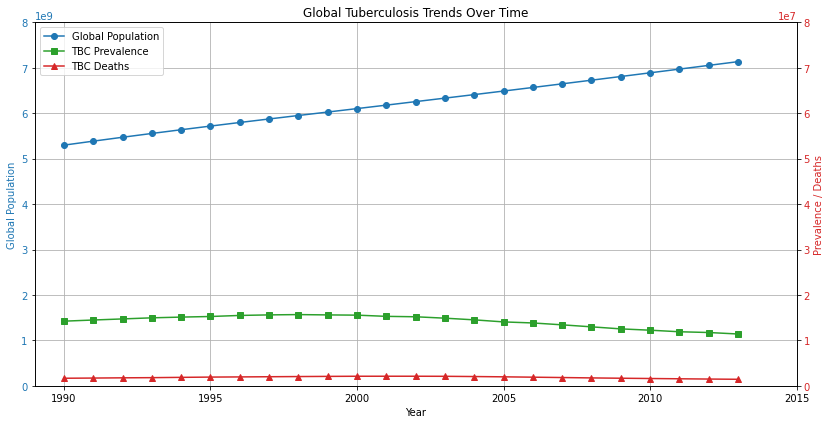

In [0]:
df_global_overview = spark.sql("select * from hive_metastore.gold.mart_global_overview")

pd_global_overview = df_global_overview.toPandas()

# Create the figure and the first axis (left y-axis)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot global population on the left y-axis
ax1.plot(pd_global_overview['year'], pd_global_overview['global_population'], color='tab:blue', marker='o', label='Global Population')
ax1.set_xlabel('Year')
ax1.set_ylabel('Global Population', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create the second axis (right y-axis)
ax2 = ax1.twinx()

# Plot prevalence and deaths on the right y-axis
ax2.plot(pd_global_overview['year'], pd_global_overview['global_prevalence'], color='tab:green', marker='s', label='TBC Prevalence')
ax2.plot(pd_global_overview['year'], pd_global_overview['global_tbc_deaths'], color='tab:red', marker='^', label='TBC Deaths')
ax2.set_ylabel('Prevalence / Deaths', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Title and grid
plt.title('Global Tuberculosis Trends Over Time')
ax1.grid(True)
fig.tight_layout()
plt.xticks(rotation=45)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Set axis limits
ax1.set_ylim([0_000_000_000, 8_000_000_000])  # Global population range
ax2.set_ylim([0, 80_000_000])                # For prevalence & deaths
ax1.set_xlim([1989, 2015])                   # Year range

# Show plot
plt.show()

We can see that as the global population increases throughout the chart, tuberculosis prevalence also rises at first, but starts to decline after the year 2000. Nonetheless, global deaths appear to change only slightly.

Now we will take a closer look into global prevalence and deaths, so we can do a more accurate analysis on global deaths.

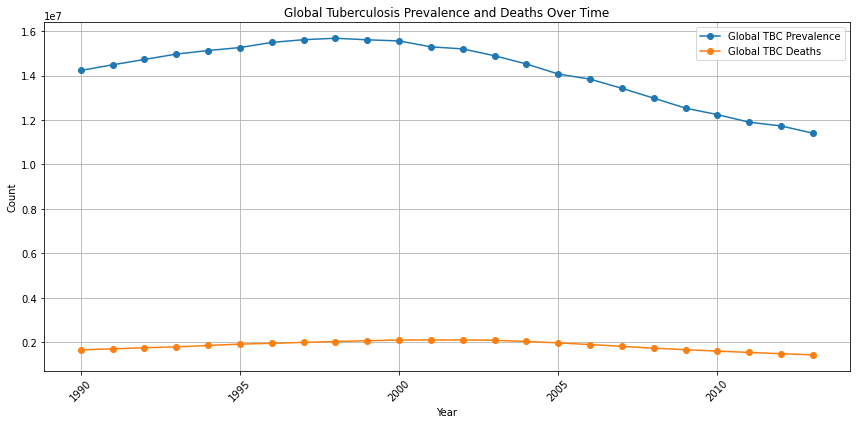

In [0]:
# Step 3: Plotting
plt.figure(figsize=(12, 6))
plt.plot(pd_global_overview['year'], pd_global_overview['global_prevalence'], label='Global TBC Prevalence', marker='o')
plt.plot(pd_global_overview['year'], pd_global_overview['global_tbc_deaths'], label='Global TBC Deaths', marker='o')

# Step 4: Styling
plt.title('Global Tuberculosis Prevalence and Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Step 5: Show the plot
plt.show()

Here we can see that also rises at first and starts to decline after the year 2000, just as the global prevalence.

## 7.2 Region Overview

### 7.2.1 Data Modeling

Here we will crate the tables for the region analysis, by using the same approach as section 7.1.1.

In [0]:
%sql
select
  regns.region_code,
  fact.year,
  sum(fact.total_population) as region_population,
  round(sum(fact.tbc_prevalence),2) as region_prevalence,
  round(sum(fact.tbc_deaths_hiv) + sum(fact.tbc_deaths_no_hiv), 2) as region_tbc_deaths
from
  hive_metastore.gold.fact_tuberculosis_burden fact
  left join hive_metastore.gold.dim_country cntry on fact.idfk_country = cntry.idpk_country
  left join hive_metastore.gold.dim_who_regions regns on cntry.idfk_region = regns.idpk_region
group by all
order by 1, 2

region_code,year,region_population,region_prevalence,region_tbc_deaths
AFR,1990,502970338,2054299.0,477914.1
AFR,1991,517234627,2086077.0,503512.1
AFR,1992,531812865,2130460.0,533609.1
AFR,1993,546641498,2167257.0,561692.1
AFR,1994,561636401,2217745.0,599988.1
AFR,1995,576744821,2275433.0,629914.2
AFR,1996,591951348,2327456.0,659807.9
AFR,1997,607297345,2399492.0,702485.2
AFR,1998,622859385,2452198.0,730337.7
AFR,1999,638744959,2508026.0,757056.2


Creating the table

In [0]:
%sql
create or replace table hive_metastore.gold.mart_region_overview (
    year bigint comment 'Year',
    region_code string comment 'Region code',
    region_population bigint comment 'The region population',
    region_prevalence bigint comment 'The region tuberculosis prevalence',
    region_tbc_deaths bigint comment 'The region tuberculosis deaths'
) using delta;

Populating the table

In [0]:
%sql
insert into hive_metastore.gold.mart_region_overview (region_code, year, region_population, region_prevalence, region_tbc_deaths) 
select
  regns.region_code,
  fact.year,
  sum(fact.total_population) as region_population,
  round(sum(fact.tbc_prevalence),2) as region_prevalence,
  round(sum(fact.tbc_deaths_hiv) + sum(fact.tbc_deaths_no_hiv), 2) as region_tbc_deaths
from
  hive_metastore.gold.fact_tuberculosis_burden fact
  left join hive_metastore.gold.dim_country cntry on fact.idfk_country = cntry.idpk_country
  left join hive_metastore.gold.dim_who_regions regns on cntry.idfk_region = regns.idpk_region
group by all
order by 1, 2


num_affected_rows,num_inserted_rows
144,144


Table catalog

In [0]:
%sql
describe table hive_metastore.gold.mart_region_overview

col_name,data_type,comment
year,bigint,Year
region_code,string,Region code
region_population,bigint,The region population
region_prevalence,bigint,The region tuberculosis prevalence
region_tbc_deaths,bigint,The region tuberculosis deaths


### 7.2.2 Data Analysis

There are 6 different regions, which means that if we plot every region for each metric in the same chart, it would be very difficult to analyze it. So here we splitted the analysis in 3 graphics, each one for a metric and all the regions.

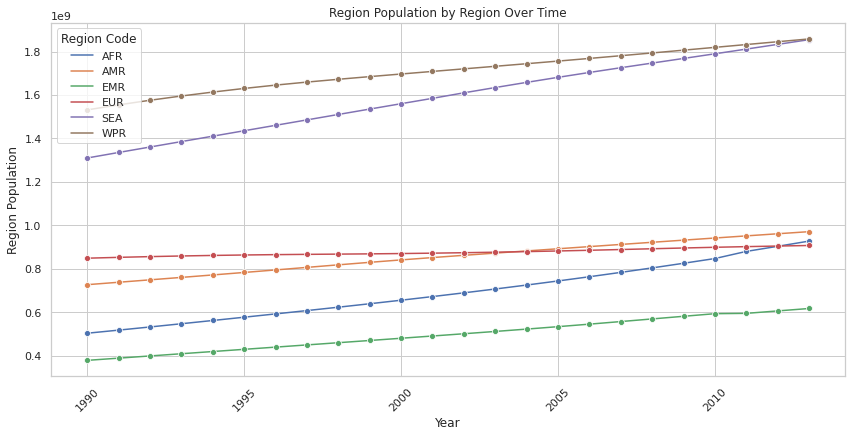

In [0]:
df_region_overview = spark.sql("select * from hive_metastore.gold.mart_region_overview")

# Convert Spark DataFrame to Pandas
pd_region_overview = df_region_overview.toPandas()

# Set up the plot style
sns.set(style="whitegrid")

metric = 'region_population'
plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_region_overview, x='year', y=metric, hue='region_code', marker='o')

# Plot styling
plt.title(f'{metric.replace("_", " ").title()} by Region Over Time')
plt.xlabel('Year')
plt.ylabel(metric.replace("_", " ").title())
plt.legend(title='Region Code')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


By analyzing the region total population, we can see that all regions shows an increase of its population.

Now we will analyze the region prevalence.

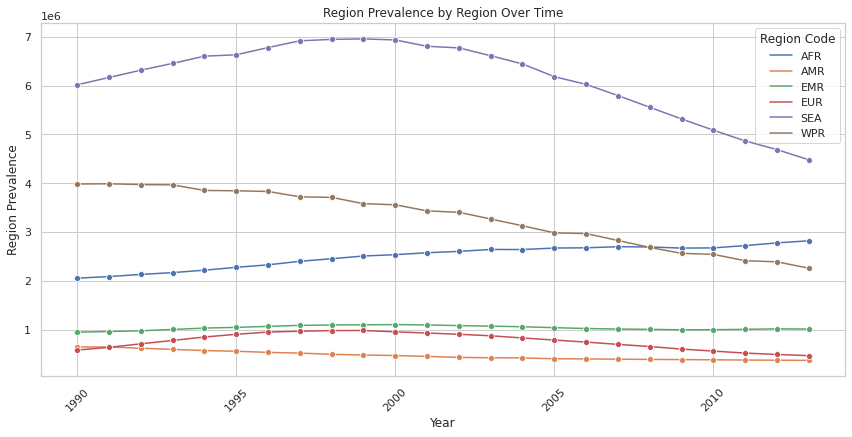

In [0]:
df_region_overview = spark.sql("select * from hive_metastore.gold.mart_region_overview")

# Convert Spark DataFrame to Pandas
pd_region_overview = df_region_overview.toPandas()

# Set up the plot style
sns.set(style="whitegrid")

metric = 'region_prevalence'
plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_region_overview, x='year', y=metric, hue='region_code', marker='o')

# Plot styling
plt.title(f'{metric.replace("_", " ").title()} by Region Over Time')
plt.xlabel('Year')
plt.ylabel(metric.replace("_", " ").title())
plt.legend(title='Region Code')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


By analyzing the region trend we had a sad insight: just the african region increased over all the years of data collected. Which could be related to the GDP, but as we don't have this information we cannot analyze this metric. Also, it is really surprising the south-east asia tuberculosis prevalence.

Now we will analyze the tuberculosis death.

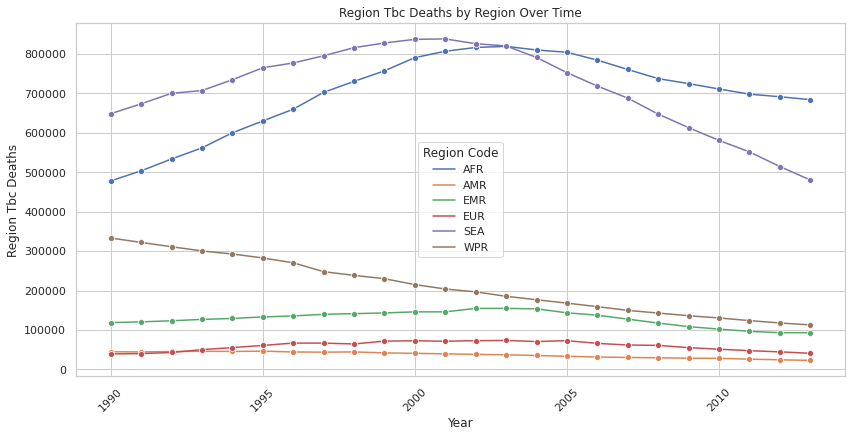

In [0]:
df_region_overview = spark.sql("select * from hive_metastore.gold.mart_region_overview")

# Convert Spark DataFrame to Pandas
pd_region_overview = df_region_overview.toPandas()

# Sort for consistent plotting
# pd_region_overview = pd_region_overview.sort_values(by=["year", "region_code"])

# Define the metrics you want to plot
metrics = ['region_population', 'region_prevalence', 'region_tbc_deaths']

# Set up the plot style
sns.set(style="whitegrid")

# Loop through each metric and create a line plot
# for metric in metrics:
metric = 'region_tbc_deaths'
plt.figure(figsize=(12, 6))
sns.lineplot(data=pd_region_overview, x='year', y=metric, hue='region_code', marker='o')

# Plot styling
plt.title(f'{metric.replace("_", " ").title()} by Region Over Time')
plt.xlabel('Year')
plt.ylabel(metric.replace("_", " ").title())
plt.legend(title='Region Code')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


Although the tuberculosis prevalence has increased in almost all years in the african region, they managed to descrease the total deaths over the years. It is also remarkable the amount of deaths in the south-east asia is lower than the african, even that they have a highest prevalence than the africans.

## 7.3 Metrics per 100k inhabitants analysis

### 7.3.1 Data Modeling

Here we will analyze the metrics per 100k inhabitants using just the SQL, with no charts. First of all we need to create the table that will allow us to perform our analysis. The code below shows the query that will be used to populate the table.

In [0]:
%sql
select
  fact.year,
  regns.region_name,
  cntry.country_name,
  fact.tbc_incidence_per_100k,
  fact.tbc_prevalence_per_100k,
  fact.tbc_incidence_hiv_per_100k,
  fact.tbc_mortality_hiv_per_100k,
  fact.tbc_mortality_no_hiv_per_100k
from
  hive_metastore.gold.fact_tuberculosis_burden fact
  left join hive_metastore.gold.dim_country cntry on fact.idfk_country = cntry.idpk_country
  left join hive_metastore.gold.dim_who_regions regns on cntry.idfk_region = regns.idpk_region
limit 10

year,region_name,country_name,tbc_incidence_per_100k,tbc_prevalence_per_100k,tbc_incidence_hiv_per_100k,tbc_mortality_hiv_per_100k,tbc_mortality_no_hiv_per_100k
1990,Eastern Mediterranean Region,Afghanistan,189.0,306.0,0.11,0.04,37.0
1991,Eastern Mediterranean Region,Afghanistan,191.0,343.0,0.13,0.06,46.0
1992,Eastern Mediterranean Region,Afghanistan,191.0,371.0,0.16,0.08,54.0
1993,Eastern Mediterranean Region,Afghanistan,189.0,392.0,0.19,0.11,60.0
1994,Eastern Mediterranean Region,Afghanistan,188.0,410.0,0.21,0.13,65.0
1995,Eastern Mediterranean Region,Afghanistan,188.0,424.0,0.23,0.15,69.0
1996,Eastern Mediterranean Region,Afghanistan,188.0,438.0,0.25,0.17,71.0
1997,Eastern Mediterranean Region,Afghanistan,189.0,448.0,0.28,0.19,72.0
1998,Eastern Mediterranean Region,Afghanistan,189.0,454.0,0.3,0.21,72.0
1999,Eastern Mediterranean Region,Afghanistan,190.0,446.0,0.32,0.22,71.0


Creating table

In [0]:
%sql
create or replace table hive_metastore.gold.mart_100k_inhabitant_analysis (
    year bigint comment 'Year',
    region_name string comment 'Region code',
    country_name string comment 'Country name',
    tbc_incidence_per_100k bigint comment 'Estimated incidence (all forms) per 100.000 population',
    tbc_prevalence_per_100k bigint comment 'Estimated prevalence of TB (all forms) per 100.000 population',
    tbc_incidence_hiv_per_100k bigint comment 'Estimated incidence of TB cases who are HIV-positive per 100.000 population',
    tbc_mortality_hiv_per_100k bigint comment 'Estimated mortality of TB cases who are HIV-positive, per 100.000 population',
    tbc_mortality_no_hiv_per_100k bigint comment 'Estimated mortality of TB cases (all forms, excluding HIV) per 100.000 population'
) using delta;

Populating table

In [0]:
%sql
insert into hive_metastore.gold.mart_100k_inhabitant_analysis (year, region_name, country_name, tbc_incidence_per_100k, tbc_prevalence_per_100k, tbc_incidence_hiv_per_100k, tbc_mortality_hiv_per_100k, tbc_mortality_no_hiv_per_100k)
select
  fact.year,
  regns.region_name,
  cntry.country_name,
  fact.tbc_incidence_per_100k,
  fact.tbc_prevalence_per_100k,
  fact.tbc_incidence_hiv_per_100k,
  fact.tbc_mortality_hiv_per_100k,
  fact.tbc_mortality_no_hiv_per_100k
from
  hive_metastore.gold.fact_tuberculosis_burden fact
  left join hive_metastore.gold.dim_country cntry on fact.idfk_country = cntry.idpk_country
  left join hive_metastore.gold.dim_who_regions regns on cntry.idfk_region = regns.idpk_region

num_affected_rows,num_inserted_rows
5120,5120


Table catalog

In [0]:
%sql
describe table hive_metastore.gold.mart_100k_inhabitant_analysis

col_name,data_type,comment
year,bigint,Year
region_name,string,Region code
country_name,string,Country name
tbc_incidence_per_100k,bigint,Estimated incidence (all forms) per 100.000 population
tbc_prevalence_per_100k,bigint,Estimated prevalence of TB (all forms) per 100.000 population
tbc_incidence_hiv_per_100k,bigint,Estimated incidence of TB cases who are HIV-positive per 100.000 population
tbc_mortality_hiv_per_100k,bigint,"Estimated mortality of TB cases who are HIV-positive, per 100.000 population"
tbc_mortality_no_hiv_per_100k,bigint,"Estimated mortality of TB cases (all forms, excluding HIV) per 100.000 population"


### 7.3.2 Data Analysis

Now we will analyze the countries and regions that have the worst indices per 100k inhabitants.

#### 7.3.2.1 Incidence per 100k

The query result below show us that the african region definatly had the worst measures, with Namibia being the worst country regarding the incidence per 100k inhabitants.

In [0]:
%sql
select
  year,
  region_name,
  country_name,
  tbc_incidence_per_100k
from
  hive_metastore.gold.mart_100k_inhabitant_analysis
order by tbc_incidence_per_100k desc
limit 10

year,region_name,country_name,tbc_incidence_per_100k
2002,African Region,Namibia,1662
2003,African Region,Namibia,1660
2001,African Region,Namibia,1615
2004,African Region,Namibia,1611
2005,African Region,Namibia,1518
2000,African Region,Namibia,1514
2006,African Region,Namibia,1389
2013,African Region,Swaziland,1382
1999,African Region,Namibia,1356
2012,African Region,Swaziland,1347


#### 7.3.2.2 Prevalence per 100k

When talking about prevalence, the query below show us that Bhutan, in the south-east asia region, had the worst result in 1990.

In [0]:
%sql
select
  year,
  region_name,
  country_name,
  tbc_prevalence_per_100k
from
  hive_metastore.gold.mart_100k_inhabitant_analysis
order by tbc_prevalence_per_100k desc
limit 10

year,region_name,country_name,tbc_prevalence_per_100k
1990,South-East Asia Region,Bhutan,1762
1993,African Region,Central African Republic,1736
1994,African Region,Central African Republic,1736
1998,European Region,Azerbaijan,1725
1992,African Region,Central African Republic,1714
1997,European Region,Azerbaijan,1701
1999,European Region,Azerbaijan,1696
1995,African Region,Central African Republic,1686
1991,African Region,Central African Republic,1679
1992,Western Pacific Region,Cambodia,1667


#### 7.3.2.3 Incidence HIV per 100k

The region that had the worst tuberculosis incidence on HIV population was Swaziland, in the african region. It is also remarkable that this country had the worst result in several years.

In [0]:
%sql
select
  year,
  region_name,
  country_name,
  tbc_incidence_hiv_per_100k
from
  hive_metastore.gold.mart_100k_inhabitant_analysis
order by tbc_incidence_hiv_per_100k desc
limit 10

year,region_name,country_name,tbc_incidence_hiv_per_100k
2010,African Region,Swaziland,1063
2013,African Region,Swaziland,1038
2011,African Region,Swaziland,1028
2009,African Region,Swaziland,1024
2012,African Region,Swaziland,1015
2003,African Region,Namibia,1004
2008,African Region,Swaziland,990
2002,African Region,Namibia,985
2004,African Region,Namibia,977
2006,African Region,Lesotho,959


#### 7.3.2.4 Mortality HIV per 100k

When it comes to mortality in the HIV population, Namibia from the african region takes the first place again.

In [0]:
%sql
select
  year,
  region_name,
  country_name,
  tbc_mortality_hiv_per_100k
from
  hive_metastore.gold.mart_100k_inhabitant_analysis
order by tbc_mortality_hiv_per_100k desc
limit 10

year,region_name,country_name,tbc_mortality_hiv_per_100k
2002,African Region,Namibia,481
2003,African Region,Namibia,480
2001,African Region,Namibia,452
2004,African Region,Namibia,452
1998,African Region,Central African Republic,437
1997,African Region,Central African Republic,430
1999,African Region,Central African Republic,429
2005,African Region,Lesotho,420
2004,African Region,Lesotho,420
2000,African Region,Central African Republic,411


#### 7.3.2.5 Mortality No HIV per 100k

But when we consider only the population with no HIV, than the Central African Republic appears for the first time, having the worst result in 1993.

In [0]:
%sql
select
  year,
  region_name,
  country_name,
  tbc_mortality_no_hiv_per_100k
from
  hive_metastore.gold.mart_100k_inhabitant_analysis
order by tbc_mortality_no_hiv_per_100k desc
limit 10

year,region_name,country_name,tbc_mortality_no_hiv_per_100k
1993,African Region,Central African Republic,278
1990,South-East Asia Region,Bhutan,277
1992,African Region,Central African Republic,277
1994,African Region,Central African Republic,275
1991,African Region,Central African Republic,272
1990,African Region,Central African Republic,269
1995,African Region,Central African Republic,267
1991,South-East Asia Region,Bhutan,257
1996,African Region,Central African Republic,254
1997,African Region,Central African Republic,238


# 8. Conclusion

In this work it was presented a data engineering project from scratch to the data analysis phase. We tried to apply as much good data engineering practices as we could, always trying to explain what were being done. All the data engineering approach and decisions made in this work enabled the analysis that we wanted to make, so we think they were a good approach and decisions.

But the questions that we have created at the beggining of this work could not be all of them successfully answered, at least not with the chosen dataset. So if we had dedicated more efforts during the data search phase, maybe we could find a more appropriate dataset for this work.

## 8.1 Future Works

As future works, a good place to start is to find another dataset that have the remaining information (such as GDP) that could help us to answer the questions we first create. Then, we could elaborate other analysis using both datasets - the one used in the current version of this work and the new one.